# Model identification with PySR

Identifies $\dot v = f(x, v, u)$ with one PySR search (`x_dot = v` is imposed). Training: every sample of the 500, 1000, 2000 and 2500 mg sweeps; test: the 1500 mg sweeps. The search space is the PySINDy library, and the equation is chosen on the Pareto front with the common selection rule.

## Imports

`PYTHON_JULIACALL_THREADS` must be set before PySR is imported.

In [1]:
import hashlib
import json
import os
import pickle
import platform
import re
import shutil
import sys
import warnings
from importlib.metadata import version
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "notebooks" / "pipeline").is_dir():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("Project root could not be located.")
    PROJECT_ROOT = PROJECT_ROOT.parent

# Figure style.
COLORS = {"purple": "#5E3C99", "orange": "#D55E00", "green": "#009E73",
          "blue": "#0072B2", "brown": "#8C564B", "yellow": "#E69F00"}
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "font.size": 10,
    "mathtext.fontset": "stix",
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "lines.linewidth": 1.5,
    "axes.xmargin": 0.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "path.simplify": True,
    "agg.path.chunksize": 10000,
    "axes.prop_cycle": plt.cycler(color=list(COLORS.values())),
})


def slug(name):
    return re.sub(r"[^0-9a-zA-Z]+", "_", str(name)).strip("_").lower()

# Must be set before importing PySR.
os.environ.setdefault("PYTHON_JULIACALL_THREADS", "auto")
from pysr import PySRRegressor
from pysr.julia_import import jl

print(f"PySR {version('pysr')}, Julia {jl.seval('string(VERSION)')}, "
      f"SymbolicRegression.jl {jl.seval('string(pkgversion(SymbolicRegression))')}")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
PySR 1.5.10, Julia 1.11.9, SymbolicRegression.jl 1.11.3


In [2]:
# Shared protocol: TEST_LEVEL_MG (both sweeps) is the test set; the other levels train.
# Predictions are made at the measured states; NRMSE = RMSE / std(measured).
LEVELS_MG = (500, 1000, 1500, 2000, 2500)
TEST_LEVEL_MG = 1500
TRAINING_LEVELS_MG = tuple(level for level in LEVELS_MG if level != TEST_LEVEL_MG)
ROLES = ("train", "test")
PROTOCOL_DESCRIPTION = (f"single train/test split: test level {TEST_LEVEL_MG} mg; "
                        f"training levels {TRAINING_LEVELS_MG} mg")
SWEEP_MIN_HZ, SWEEP_MAX_HZ = 50.0, 150.0
RESONANCE_BAND_HZ = (80.0, 110.0)
# Selection score on the training set: TOTAL_ERROR_WEIGHT * NRMSE
# + RESONANCE_ERROR_WEIGHT * resonance-band NRMSE. The smallest model within
# ACCEPTABLE_ERROR_INCREASE of the best score is selected.
TOTAL_ERROR_WEIGHT, RESONANCE_ERROR_WEIGHT = 0.3, 0.7
ACCEPTABLE_ERROR_INCREASE = 0.1


def excitation_level_mg(name):
    return int(re.search(r"(\d+)mg", str(name)).group(1))


def sweep_direction(name):
    return "down" if "sweep_down" in str(name) else "up"


def sweep_frequency_hz(name, t):
    """Nominal frequency, assuming a linear sweep."""
    fraction = (t - t[0]) / (t[-1] - t[0])
    if sweep_direction(name) == "down":
        return SWEEP_MAX_HZ - fraction * (SWEEP_MAX_HZ - SWEEP_MIN_HZ)
    return SWEEP_MIN_HZ + fraction * (SWEEP_MAX_HZ - SWEEP_MIN_HZ)


def resonance_band_mask(name, t):
    """Samples whose nominal sweep frequency lies in the resonance band."""
    frequency = sweep_frequency_hz(name, t)
    return (frequency >= RESONANCE_BAND_HZ[0]) & (frequency <= RESONANCE_BAND_HZ[1])


def signal_role(name):
    """Split role of an experiment: 'test' at the test level, 'train' otherwise."""
    return "test" if excitation_level_mg(name) == TEST_LEVEL_MG else "train"


def check_signals(signals, require_all_levels=True):
    names = [s["name"] for s in signals]
    if len(set(names)) != len(names):
        raise ValueError("Signal names must be unique.")
    found = {}
    for signal in signals:
        level = excitation_level_mg(signal["name"])
        if level not in LEVELS_MG:
            raise ValueError(f"Unknown excitation level: {signal['name']}")
        found.setdefault(level, []).append(sweep_direction(signal["name"]))
        arrays = [np.asarray(signal[k], dtype=float).reshape(-1) for k in ("t", "x", "v", "u", "v_dot")]
        if len({len(a) for a in arrays}) != 1 or len(arrays[0]) < 2:
            raise ValueError(f"Mismatched array lengths: {signal['name']}")
        if not all(np.isfinite(a).all() for a in arrays):
            raise ValueError(f"Nonfinite data: {signal['name']}")
        if np.any(np.diff(arrays[0]) <= 0):
            raise ValueError(f"Time must increase: {signal['name']}")
    for level in (LEVELS_MG if require_all_levels else found):
        if sorted(found.get(level, [])) != ["down", "up"]:
            raise ValueError(f"Level {level} mg needs exactly one upward and one downward sweep.")
    return sorted(signals, key=lambda s: (excitation_level_mg(s["name"]), s["name"]))


def split_signals(signals):
    """Single train/test split by excitation level."""
    signals = check_signals(signals)
    return {"test_level_mg": TEST_LEVEL_MG, "fit_levels_mg": TRAINING_LEVELS_MG,
            "fit": [s for s in signals if signal_role(s["name"]) == "train"],
            "test": [s for s in signals if signal_role(s["name"]) == "test"]}


def split_table(split):
    rows = []
    for role, key, levels in (("train", "fit", split["fit_levels_mg"]),
                              ("test", "test", (split["test_level_mg"],))):
        rows.append({"role": role, "levels_mg": tuple(levels), "experiments": len(split[key]),
                     "samples": sum(len(s["t"]) for s in split[key])})
    return pd.DataFrame(rows)


def scores(measured, predicted, resonance_mask, weights):
    residual = measured - predicted
    rmse = np.sqrt(np.mean(residual ** 2))
    nrmse = rmse / np.std(measured)
    r2 = 1.0 - np.sum(residual ** 2) / np.sum((measured - np.mean(measured)) ** 2)
    resonance = (np.sqrt(np.mean(residual[resonance_mask] ** 2))
                 / np.std(measured[resonance_mask]))
    return {"total_RMSE": rmse, "total_NRMSE": nrmse, "total_R2": r2,
            "resonance_NRMSE": resonance,
            "weighted_score": weights[0] * nrmse + weights[1] * resonance}


def build_series(signals):
    series = {}
    for signal in check_signals(signals, require_all_levels=False):
        name = signal["name"]
        t, x, v, u, measured = (np.asarray(signal[k], dtype=float).reshape(-1)
                                for k in ("t", "x", "v", "u", "v_dot"))
        series[name] = {
            "level_mg": excitation_level_mg(name), "sweep": sweep_direction(name),
            "role": signal_role(name),
            "time": t - t[0], "x": x, "v": v, "input": u,
            "experimental_acceleration": measured,
            "instantaneous_frequency_hz": sweep_frequency_hz(name, t),
            "resonance_mask": resonance_band_mask(name, t),
            "model_predictions": {},
        }
    return series


def add_predictions(series, model_functions, names=None):
    """Store each model's predictions under the role of each experiment (or only `names`)."""
    for name, record in series.items():
        if names is not None and name not in names:
            continue
        x, v, u = record["x"], record["v"], record["input"]
        for model_name, function in model_functions.items():
            predicted = np.broadcast_to(np.asarray(function(x, v, u), dtype=float),
                                        record["experimental_acceleration"].shape).astype(float)
            if not np.isfinite(predicted).all():
                raise ValueError(f"Nonfinite prediction: {model_name} on {name}")
            record["model_predictions"].setdefault(model_name, {})[record["role"]] = predicted
    return series


def summarize_models(series, weights=(TOTAL_ERROR_WEIGHT, RESONANCE_ERROR_WEIGHT)):
    """Metric tables per signal, per level and per role (train/test, pooled)."""
    per_signal, models = [], []
    for name, record in series.items():
        for model, roles in record["model_predictions"].items():
            if model not in models:
                models.append(model)
            for role, predicted in roles.items():
                per_signal.append({
                    "signal": name, "level_mg": record["level_mg"], "sweep": record["sweep"],
                    "model": model, "role": role,
                    **scores(record["experimental_acceleration"], predicted,
                             record["resonance_mask"], weights)})
    per_level, aggregate = [], []
    for model in models:
        names = [n for n, r in series.items() if model in r["model_predictions"]]

        def pooled(group):
            measured = np.concatenate([series[n]["experimental_acceleration"] for n in group])
            mask = np.concatenate([series[n]["resonance_mask"] for n in group])
            predicted = np.concatenate([series[n]["model_predictions"][model][series[n]["role"]]
                                        for n in group])
            return {"signals": len(group), "samples": len(measured),
                    **scores(measured, predicted, mask, weights)}

        for level in sorted({series[n]["level_mg"] for n in names}):
            group = [n for n in names if series[n]["level_mg"] == level]
            per_level.append({"level_mg": level, "role": series[group[0]]["role"],
                              "model": model, **pooled(group)})
        for role in ROLES:
            group = [n for n in names if series[n]["role"] == role]
            if group:
                aggregate.append({"model": model, "role": role,
                                  "levels_mg": tuple(sorted({series[n]["level_mg"] for n in group})),
                                  **pooled(group)})
    return (pd.DataFrame(per_signal), pd.DataFrame(per_level), pd.DataFrame(aggregate))


def regression_block(library, target, resonance_mask):
    """Library, target and resonance mask of one experiment (all samples)."""
    library = np.asarray(library, dtype=float)
    target = np.asarray(target, dtype=float).reshape(-1)
    resonance_mask = np.asarray(resonance_mask, dtype=bool).reshape(-1)
    if library.shape[0] != len(target) or len(resonance_mask) != len(target):
        raise ValueError("Library, target and resonance mask must have the same number of samples.")
    return {"Theta": library, "y": target, "resonance_mask": resonance_mask, "samples": len(target)}


def coefficient_scores(theta, blocks):
    """Pooled NRMSE, resonance-band NRMSE and selection score of a coefficient vector."""
    residual = np.concatenate([b["y"] - b["Theta"] @ theta for b in blocks])
    measured = np.concatenate([b["y"] for b in blocks])
    mask = np.concatenate([b["resonance_mask"] for b in blocks])
    total = np.sqrt(np.mean(residual ** 2)) / np.std(measured)
    resonance = np.sqrt(np.mean(residual[mask] ** 2)) / np.std(measured[mask])
    return {"nrmse": total, "resonance_nrmse": resonance,
            "score": TOTAL_ERROR_WEIGHT * total + RESONANCE_ERROR_WEIGHT * resonance}


def within_tolerance(results, score_column="training_score"):
    """Rows whose score is within ACCEPTABLE_ERROR_INCREASE of the best finite score."""
    finite = results[np.isfinite(results[score_column])]
    limit = finite[score_column].min() * (1.0 + ACCEPTABLE_ERROR_INCREASE) + 1e-14
    return finite[finite[score_column] <= limit]

In [3]:
# Line styles: solid = test, dashed = train.
ROLE_STYLES = {"train": "--", "test": "-"}
ROLE_LABELS = {"train": "Train", "test": "Test"}


def plot_diagnostics(series, folder):
    scales = {}
    folder = Path(folder)
    folder.mkdir(parents=True, exist_ok=True)
    for name, record in series.items():
        label = f"{record['level_mg']} mg, sweep {record['sweep']}"
        time, x, v, u = record["time"], record["x"], record["v"], record["input"]
        measured, mask = record["experimental_acceleration"], record["resonance_mask"]
        predictions = [(model, role, predicted)
                       for model, roles in record["model_predictions"].items()
                       for role, predicted in roles.items()]
        tip = measured + u
        x_scale, v_scale, tip_scale = (max(np.max(np.abs(a)), np.finfo(float).eps)
                                       for a in (x, v, tip))
        scales[name] = {"x_scale": x_scale, "v_scale": v_scale, "a_tip_scale": tip_scale,
                        "level_mg": record["level_mg"], "comparison_points": len(x),
                        "normalization": "maximum absolute experimental value"}

        for window, tag in [(slice(None), "time"), (mask, "resonance")]:
            fig, ax = plt.subplots()
            ax.plot(time[window], measured[window], color="k", lw=1.0,
                    label=f"Experimental - {label}")
            for model, role, predicted in predictions:
                ax.plot(time[window], predicted[window], ROLE_STYLES[role], lw=0.4,
                        alpha=0.55, label=f"{model} ({ROLE_LABELS[role]})")
            ax.set_xlabel("Time [s]")
            ax.set_ylabel("Relative acceleration [m/s$^2$]")
            ax.legend(loc="upper right")
            fig.savefig(folder / f"one_step_{tag}_{slug(name)}.pdf", format="pdf")
            plt.show()
            plt.close(fig)

        fig, ax = plt.subplots()
        for model, role, predicted in predictions:
            ax.scatter(measured, predicted, s=2, alpha=0.2, rasterized=True,
                       label=f"{model} ({ROLE_LABELS[role]})")
        limits = [float(measured.min()), float(measured.max())]
        ax.plot(limits, limits, "k--", lw=1.0, label=f"Ideal - {label}")
        ax.set_xlabel("Measured $a_{\\mathrm{rel}}$ [m/s$^2$]")
        ax.set_ylabel("Predicted $a_{\\mathrm{rel}}$ [m/s$^2$]")
        ax.legend(loc="upper left")
        fig.savefig(folder / f"one_step_parity_{slug(name)}.pdf", format="pdf")
        plt.show()
        plt.close(fig)

        cuts = [(v, v_scale, np.abs(x / x_scale) <= 1e-3, "velocity, $v^*$", "velocity"),
                (x, x_scale, np.abs(v / v_scale) <= 1e-3, "displacement, $x^*$", "displacement")]
        for axis, scale, cut, axis_label, tag in cuts:
            fig, ax = plt.subplots()
            ax.scatter(axis[cut] / scale, tip[cut] / tip_scale, s=9, color="k",
                       rasterized=True, label=f"Experimental - {label}")
            for model, role, predicted in predictions:
                ax.scatter(axis[cut] / scale, (predicted + u)[cut] / tip_scale, s=7,
                           alpha=0.5, rasterized=True, label=f"{model} ({ROLE_LABELS[role]})")
            ax.set_xlabel(f"Dimensionless {axis_label}")
            ax.set_ylabel("Dimensionless tip acceleration, $a_{\\mathrm{tip}}^*$")
            ax.legend(loc="upper left")
            fig.savefig(folder / f"dimensionless_{tag}_{slug(name)}.pdf", format="pdf")
            plt.show()
            plt.close(fig)
    return scales


def plot_level_metrics(per_level, metric, ylabel, filename):
    table = per_level.assign(label=per_level["model"] + " (" + per_level["role"].map(ROLE_LABELS) + ")")
    table = table.pivot(index="level_mg", columns="label", values=metric)
    fig, ax = plt.subplots()
    table.plot.bar(ax=ax)
    ax.set(xlabel="Excitation level [mg]", ylabel=ylabel)
    ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=7)
    fig.savefig(filename)
    plt.show()
    plt.close(fig)
    return table

In [4]:
RESULTS_DIR = PROJECT_ROOT / "results"
PREPARED_FILE = RESULTS_DIR / "prepared_signals.pkl"
PYSINDY_RESULTS_FILE = RESULTS_DIR / "pysindy_results.pkl"
PYSR_OUTPUT_DIR = RESULTS_DIR / "pysr_search"  # PySR's own files: hall_of_fame.csv, checkpoint.pkl
FIGURES_DIR = PROJECT_ROOT / "figures" / "pipeline" / "4_pysr"
for folder in (RESULTS_DIR, PYSR_OUTPUT_DIR, FIGURES_DIR):
    folder.mkdir(parents=True, exist_ok=True)
if not PREPARED_FILE.exists():
    raise FileNotFoundError("Run notebook 2 to create results/prepared_signals.pkl.")
if not PYSINDY_RESULTS_FILE.exists():
    raise FileNotFoundError("Run 4_pysindy.ipynb first: PySR searches the PySINDy library at the degree it selected.")

## 1. Data and split

The training matrix stacks every sample of the eight training sweeps; the 1500 mg sweeps are kept for the test.

In [5]:
with PREPARED_FILE.open("rb") as file:
    prepared_hash = hashlib.file_digest(file, "sha256").hexdigest()
    file.seek(0)
    spectral_signals = pickle.load(file)["spectral_signals"]
all_signals = check_signals(spectral_signals)
split = split_signals(all_signals)
split_summary = split_table(split)
display(split_summary)
display(pd.DataFrame([{"signal": s["name"], "level_mg": excitation_level_mg(s["name"]),
                       "sweep": sweep_direction(s["name"]), "role": signal_role(s["name"]),
                       "samples": len(s["t"])} for s in all_signals]))


def stacked(signals, key):
    return np.concatenate([np.asarray(s[key], dtype=float).reshape(-1) for s in signals])


FEATURE_NAMES = ["x", "v", "u"]
X_train = np.column_stack([stacked(split["fit"], key) for key in FEATURE_NAMES])
y_train = stacked(split["fit"], "v_dot")
resonance_train = np.concatenate([resonance_band_mask(s["name"], np.asarray(s["t"], dtype=float).reshape(-1))
                                  for s in split["fit"]])
if any(signal_role(s["name"]) != "train" for s in split["fit"]):
    raise RuntimeError("A test experiment entered the training matrix.")
print(f"Training matrix: {X_train.shape[0]:,} samples x {X_train.shape[1]} variables (x, v, u), "
      f"{int(resonance_train.sum()):,} of them in the {RESONANCE_BAND_HZ[0]:g}-{RESONANCE_BAND_HZ[1]:g} Hz band. "
      "Every training sample is used: no subsampling, no compression.")

,role,levels_mg,experiments,samples
0,train,"(500, 1000, 2000, 2500)",8,3211138
1,test,"(1500,)",2,802753


,signal,level_mg,sweep,role,samples
0,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,down,train,401408
1,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,up,train,401408
2,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,down,train,401377
3,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,up,train,401376
4,relative_acceleration_000mA_1500mg_50-150_Hz_s...,1500,down,test,401377
5,relative_acceleration_000mA_1500mg_50-150_Hz_s...,1500,up,test,401376
6,relative_acceleration_000mA_2000mg_50-150_Hz_s...,2000,down,train,401408
7,relative_acceleration_000mA_2000mg_50-150_Hz_s...,2000,up,train,401408
8,relative_acceleration_000mA_2500mg_50-150_Hz_s...,2500,down,train,401377
9,relative_acceleration_000mA_2500mg_50-150_Hz_s...,2500,up,train,401376


Training matrix: 3,211,138 samples x 3 variables (x, v, u), 963,340 of them in the 80-110 Hz band. Every training sample is used: no subsampling, no compression.


## 2. Search space

Same space as PySINDy: polynomials in `x, v, u` up to the degree selected in `4_pysindy`, with `u` at most to the first power and no constant. Operators: `+`, `-`, `*`. A custom `loss_function` returns an infinite loss outside this space and the mean squared error otherwise.

In [6]:
with PYSINDY_RESULTS_FILE.open("rb") as file:
    pysindy_results = pickle.load(file)
if pysindy_results["protocol"]["test_level_mg"] != TEST_LEVEL_MG:
    raise ValueError("The PySINDy results were saved with another test level; rerun 4_pysindy.ipynb.")
if set(pysindy_results["signal_names"]) != {s["name"] for s in all_signals}:
    raise ValueError("The PySINDy results were computed on other experiments; rerun 4_pysindy.ipynb.")
POLYNOMIAL_DEGREE = int(pysindy_results["configuration"]["selected_polynomial_degree"])
MAX_INPUT_POWER = 1
PYSINDY_LIBRARY = {tuple(int(p) for p in powers) for powers in pysindy_results["models"]["STLSQ"]["polynomial_powers"]
                   if sum(powers) <= POLYNOMIAL_DEGREE}
degree_study = pysindy_results["identification_studies"]["polynomial_degree"].set_index("degree")
DENSE_REFERENCE = {key: float(degree_study.loc[POLYNOMIAL_DEGREE, column]) for key, column in
                   [("training_NRMSE", "training_nrmse"), ("training_resonance_NRMSE", "training_resonance_nrmse"),
                    ("training_score", "training_score"), ("number_of_terms", "active_terms")]}
PYSINDY_MODELS = {name: {"terms": record["active_polynomial_terms"],
                         "number_of_terms": int(record["active_acceleration_terms"]),
                         "diagnostics": record["physical_diagnostics"]}
                  for name, record in pysindy_results["models"].items()}
PYSINDY_AGGREGATE = pysindy_results["one_step"]["aggregate_metrics"].copy()
del pysindy_results  # the saved PySINDy predictions are not needed here

POLY_POWERS = [(a, b, c) for total in range(1, POLYNOMIAL_DEGREE + 1)
               for a in range(total + 1) for b in range(total + 1 - a)
               for c in [total - a - b] if c <= MAX_INPUT_POWER]
if set(POLY_POWERS) != PYSINDY_LIBRARY:
    raise ValueError("The PySR search space differs from the PySINDy library at the selected degree.")


def monomial_name(a, b, c):
    return "*".join(f"{name}^{power}" if power > 1 else name
                    for name, power in (("x", a), ("v", b), ("u", c)) if power) or "1"


print(f"Degree selected by 4_pysindy.ipynb on the training levels: {POLYNOMIAL_DEGREE}; "
      f"{len(POLY_POWERS)} candidate monomials (identical to the PySINDy library):")
print(", ".join(monomial_name(*p) for p in POLY_POWERS))
print(f"Dense least squares on the 35 monomials (accuracy ceiling of the space): training NRMSE "
      f"{DENSE_REFERENCE['training_NRMSE']:.5f}, training score {DENSE_REFERENCE['training_score']:.5f}")

POLYNOMIAL_SPACE_LOSS = """
function polynomial_space_loss(tree, dataset::Dataset{T,L}, options, idx)::L where {T,L}
    # (upper bound of the total degree, upper bound of the power of u, value at the origin)
    function properties(node)
        if node.degree == 0
            return node.constant ? (0, 0, Float64(node.val)) : (1, Int(node.feature == 3), 0.0)
        elseif node.degree != 2
            return (0, 0, NaN)  # unary operators are not part of the space
        end
        dl, ul, cl = properties(node.l)
        dr, ur, cr = properties(node.r)
        op = options.operators.binops[node.op]
        degree, input_power = op === (*) ? (dl + dr, ul + ur) : (max(dl, dr), max(ul, ur))
        return (degree, input_power, op(cl, cr))
    end
    degree, input_power, origin = properties(tree)
    if degree > MAX_DEGREE || input_power > MAX_INPUT_POWER || !isfinite(origin) || origin != 0
        return L(Inf)
    end
    # Default PySR objective (mean squared error) on the rows PySR asks for:
    # a minibatch during evolution (idx), all rows when idx === nothing.
    X = isnothing(idx) ? dataset.X : view(dataset.X, :, idx)
    y = isnothing(idx) ? dataset.y : view(dataset.y, idx)
    prediction, complete = eval_tree_array(tree, X, options)
    complete || return L(Inf)
    return L(sum(abs2, prediction .- y) / length(y))
end
""".replace("MAX_DEGREE", str(POLYNOMIAL_DEGREE)).replace("MAX_INPUT_POWER", str(MAX_INPUT_POWER))

Degree selected by 4_pysindy.ipynb on the training levels: 5; 35 candidate monomials (identical to the PySINDy library):
u, v, x, v*u, v^2, x*u, x*v, x^2, v^2*u, v^3, x*v*u, x*v^2, x^2*u, x^2*v, x^3, v^3*u, v^4, x*v^2*u, x*v^3, x^2*v*u, x^2*v^2, x^3*u, x^3*v, x^4, v^4*u, v^5, x*v^3*u, x*v^4, x^2*v^2*u, x^2*v^3, x^3*v*u, x^3*v^2, x^4*u, x^4*v, x^5
Dense least squares on the 35 monomials (accuracy ceiling of the space): training NRMSE 0.01496, training score 0.01463


## 3. Scaling

Variables and target are divided by their training standard deviations, so the PySR loss equals the squared training NRMSE. Equations convert back to SI units exactly:

$$\dot v = \sigma_{\dot v}\, \tilde f(x/\sigma_x, v/\sigma_v, u/\sigma_u).$$

In [7]:
feature_scales = X_train.std(axis=0)
target_scale = float(y_train.std())
if not np.all(np.isfinite(feature_scales) & (feature_scales > 0)) or not target_scale > 0:
    raise ValueError("Training scales must be finite and positive.")
X_train_scaled = X_train / feature_scales
y_train_scaled = y_train / target_scale
display(pd.DataFrame({
    "variable": ["x (relative displacement)", "v (relative velocity)", "u (base acceleration)", "v_dot (target)"],
    "unit": ["m", "m/s", "m/s^2", "m/s^2"],
    "training_std": [*feature_scales, target_scale],
}))

,variable,unit,training_std
0,x (relative displacement),m,0.000181
1,v (relative velocity),m/s,0.106911
2,u (base acceleration),m/s^2,11.742908
3,v_dot (target),m/s^2,64.382217


## 4. PySR settings

Settings that differ from the PySR defaults (listed in the table below):

* operators `+`, `-`, `*` and the custom `loss_function` (Section 2);
* `batching=True`, `batch_size=1000`: minibatches during evolution, full data for the hall of fame;
* `populations=3`; 100 iterations run as 10 warm-started blocks of 10;
* `ncycles_per_iteration=10000`, `weight_optimize=0.001`;
* `maxsize=40`; `parsimony` = dense least-squares loss / 10;
* `deterministic=True`, `parallelism="serial"`, `random_state=0`;
* fixed `output_directory` and `run_id`.

In [8]:
RANDOM_STATE = 0
SEARCH_BLOCKS = 10
ITERATIONS_PER_BLOCK = 10
RUN_ID = "4_pysr"
EXPECTED_MINIMUM_LOSS = DENSE_REFERENCE["training_NRMSE"] ** 2  # scaled loss = NRMSE^2 (Section 3)
PYSR_SETTINGS = dict(
    binary_operators=["+", "-", "*"],
    loss_function=POLYNOMIAL_SPACE_LOSS,
    maxsize=40,
    populations=3,
    niterations=ITERATIONS_PER_BLOCK,
    ncycles_per_iteration=10_000,
    weight_optimize=0.001,
    parsimony=EXPECTED_MINIMUM_LOSS / 10,
    batching=True,
    batch_size=1000,
    deterministic=True,
    parallelism="serial",
    random_state=RANDOM_STATE,
    warm_start=True,
    output_directory=str(PYSR_OUTPUT_DIR),
    run_id=RUN_ID,
    progress=False,
    verbosity=0,
)
PYSR_DEFAULTS = PySRRegressor().get_params()
settings_table = pd.DataFrame(
    [{"parameter": key, "value": ("custom polynomial-space objective (Section 2)" if key == "loss_function" else value),
      "PySR default": PYSR_DEFAULTS.get(key)} for key, value in PYSR_SETTINGS.items()]
    + [{"parameter": key, "value": PYSR_DEFAULTS[key], "PySR default": PYSR_DEFAULTS[key]}
       for key in ["population_size", "precision", "model_selection", "unary_operators", "elementwise_loss"]]
)
display(settings_table)
print(f"Total budget: {SEARCH_BLOCKS * ITERATIONS_PER_BLOCK} iterations x {PYSR_SETTINGS['populations']} populations; "
      f"parsimony = {PYSR_SETTINGS['parsimony']:.3g}")

# Silence expected PySR warnings (undefined score of the first front row, random_state note).
warnings.filterwarnings("ignore", category=RuntimeWarning, module="pysr")
warnings.filterwarnings("ignore", message="Note: Setting `random_state`")


def new_search(**overrides):
    """PySRRegressor with the settings above; its run directory is emptied first."""
    settings = {**PYSR_SETTINGS, **overrides}
    shutil.rmtree(PYSR_OUTPUT_DIR / settings["run_id"], ignore_errors=True)
    return PySRRegressor(**settings)

,parameter,value,PySR default
0,binary_operators,"[+, -, *]",None
1,loss_function,custom polynomial-space objective (Section 2),None
2,maxsize,40,30
3,populations,3,31
4,niterations,10,100
5,ncycles_per_iteration,10000,380
6,weight_optimize,0.001,0.0
7,parsimony,0.000022,0.0
8,batching,True,False
9,batch_size,1000,50


Total budget: 100 iterations x 3 populations; parsimony = 2.24e-05


## 5. Determinism check

Two one-iteration searches with the same settings and seed must return the same front.

In [9]:
RUN_DETERMINISM_CHECK = True
if RUN_DETERMINISM_CHECK:
    started = perf_counter()
    check_fronts = []
    for repeat in (1, 2):
        check_model = new_search(niterations=1, warm_start=False, run_id=f"determinism_check_{repeat}")
        check_model.fit(X_train_scaled, y_train_scaled, variable_names=FEATURE_NAMES)
        check_fronts.append(check_model.equations_[["complexity", "loss", "equation"]].reset_index(drop=True))
        shutil.rmtree(PYSR_OUTPUT_DIR / f"determinism_check_{repeat}", ignore_errors=True)
    pd.testing.assert_frame_equal(check_fronts[0], check_fronts[1])
    print(f"Identical fronts in two runs ({len(check_fronts[0])} equations each), "
          f"{perf_counter() - started:.0f} s including Julia compilation.")
    display(check_fronts[0])
    del check_model, check_fronts

Identical fronts in two runs (4 equations each), 19 s including Julia compilation.


,complexity,loss,equation
0,1,inf,-1.486706
1,3,0.037063,x * -0.98305917
2,5,0.006041,(u * -0.18074659) - x
3,15,0.004866,(-0.18074659 * u) - (-0.634911 * ((0.8203765 -...


## 6. Search

One search on all training samples, run as 10 warm-started blocks of 10 iterations; the front is recorded after each block.

In [10]:
pysr_model = new_search()
block_fronts, block_times = [], []
for block in range(1, SEARCH_BLOCKS + 1):
    started = perf_counter()
    pysr_model.fit(X_train_scaled, y_train_scaled, variable_names=FEATURE_NAMES)
    block_times.append(perf_counter() - started)
    front = pysr_model.equations_[["complexity", "loss", "score", "equation"]].copy()
    front.insert(0, "iterations", block * ITERATIONS_PER_BLOCK)
    block_fronts.append(front)
    finite = front[np.isfinite(front["loss"])]
    best = finite.loc[finite["loss"].idxmin()]
    print(f"block {block:2d}/{SEARCH_BLOCKS} ({block * ITERATIONS_PER_BLOCK:3d} iterations, "
          f"{sum(block_times) / 60:4.1f} min): {len(finite)} equations on the front; lowest loss "
          f"{best['loss']:.3e} (NRMSE {np.sqrt(best['loss']):.4f}) at complexity {int(best['complexity'])}")
search_seconds = float(sum(block_times))
print(f"Search time: {search_seconds / 60:.1f} min (serial, one core). Run directory: {pysr_model.output_directory_}\\{pysr_model.run_id_}")

block  1/10 ( 10 iterations,  1.1 min): 11 equations on the front; lowest loss 1.958e-03 (NRMSE 0.0442) at complexity 39
block  2/10 ( 20 iterations,  2.2 min): 17 equations on the front; lowest loss 1.171e-03 (NRMSE 0.0342) at complexity 39
block  3/10 ( 30 iterations,  3.3 min): 13 equations on the front; lowest loss 6.062e-04 (NRMSE 0.0246) at complexity 37
block  4/10 ( 40 iterations,  4.4 min): 14 equations on the front; lowest loss 6.062e-04 (NRMSE 0.0246) at complexity 37
block  5/10 ( 50 iterations,  5.4 min): 16 equations on the front; lowest loss 5.757e-04 (NRMSE 0.0240) at complexity 39
block  6/10 ( 60 iterations,  6.6 min): 16 equations on the front; lowest loss 5.615e-04 (NRMSE 0.0237) at complexity 35
block  7/10 ( 70 iterations,  7.7 min): 16 equations on the front; lowest loss 5.615e-04 (NRMSE 0.0237) at complexity 35
block  8/10 ( 80 iterations,  8.6 min): 17 equations on the front; lowest loss 5.615e-04 (NRMSE 0.0237) at complexity 35
block  9/10 ( 90 iterations,  9.

## 7. Pareto front

Each equation of the final front is expanded into monomials (SymPy), converted to SI units, checked against the search space and `PySRRegressor.predict`, and scored on all training samples. `number_of_terms` is the complexity shared with PySINDy; PySR's `complexity` counts tree nodes.

In [11]:
x, v, u = sp.symbols("x v u")
VARIABLES = (x, v, u)
EXPANSION_TOLERANCE = 1e-9


def polynomial_prediction(terms, x_values, v_values, u_values):
    """Value of a polynomial given as (coefficient, x power, v power, u power) terms."""
    x_values, v_values, u_values = (np.asarray(a, dtype=float) for a in (x_values, v_values, u_values))
    prediction = np.zeros(np.broadcast(x_values, v_values, u_values).shape)
    for coefficient, a, b, c in terms:
        prediction += coefficient * x_values**a * v_values**b * u_values**c
    return prediction


def polynomial_expression(terms, digits=None):
    """SymPy polynomial from (coefficient, x power, v power, u power) terms."""
    return sp.Add(*[(sp.Float(coefficient, digits) if digits else sp.Float(coefficient)) * x**a * v**b * u**c
                    for coefficient, a, b, c in terms])


def physical_diagnostics(terms):
    """Sign checks of the linear terms, as in 4_pysindy: restoring force, damping, input term."""
    coefficients = {(a, b, c): coefficient for coefficient, a, b, c in terms}
    stiffness = coefficients.get((1, 0, 0), 0.0)
    damping = coefficients.get((0, 1, 0), 0.0)
    forcing = coefficients.get((0, 0, 1), 0.0)
    restoring, damped, input_term = stiffness < 0, damping < 0, forcing != 0
    return {
        "has_restoring_force": restoring, "has_damping": damped, "has_input_term": input_term,
        "has_state_nonlinearity": any(a + b >= 2 for _, a, b, c in terms),
        "physically_valid": restoring and damped and input_term,
        "linear_natural_frequency_hz": np.sqrt(-stiffness) / (2 * np.pi) if restoring else np.nan,
        "linear_damping_ratio": -damping / (2 * np.sqrt(-stiffness)) if restoring and damped else np.nan,
    }


def expand_native(expression):
    """Monomial terms of a native (scaled) PySR expression, in scaled units and in SI units."""
    polynomial = sp.Poly(sp.expand(expression), *VARIABLES)
    scaled = [(float(c), *(int(p) for p in powers)) for powers, c in polynomial.terms()]
    largest = max((abs(c) for c, *_ in scaled), default=0.0)
    scaled = sorted((t for t in scaled if abs(t[0]) > EXPANSION_TOLERANCE * largest),
                    key=lambda t: (sum(t[1:]), POLY_POWERS.index(tuple(t[1:])) if tuple(t[1:]) in POLY_POWERS else -1))
    sx, sv, su = feature_scales
    physical = [(target_scale * c / (sx**a * sv**b * su**c_), a, b, c_) for c, a, b, c_ in scaled]
    return scaled, physical


_analysis_cache = {}


def analyse_equation(equation, expression):
    """Expansion, space check and training metrics of one native equation (cached by its string)."""
    if equation not in _analysis_cache:
        scaled_terms, terms = expand_native(expression)
        outside = [monomial_name(a, b, c) for _, a, b, c in terms if (a, b, c) not in POLY_POWERS]
        if outside or not terms:
            raise RuntimeError(f"Equation outside the search space ({outside}): {equation}")
        metrics = scores(y_train, polynomial_prediction(terms, *X_train.T), resonance_train,
                         (TOTAL_ERROR_WEIGHT, RESONANCE_ERROR_WEIGHT))
        _analysis_cache[equation] = {
            "scaled_terms": scaled_terms, "terms": terms, "number_of_terms": len(terms),
            "structure": " + ".join(monomial_name(a, b, c) for _, a, b, c in terms),
            "training_NRMSE": float(metrics["total_NRMSE"]),
            "training_resonance_NRMSE": float(metrics["resonance_NRMSE"]),
            "training_score": float(metrics["weighted_score"]), **physical_diagnostics(terms)}
    return _analysis_cache[equation]


def front_table(equations, sympy_of):
    """Analysis of every finite-loss equation of a PySR front."""
    rows = []
    for index, row in equations.iterrows():
        if not np.isfinite(row["loss"]):
            continue
        analysis = analyse_equation(row["equation"], sympy_of(index))
        rows.append({"equation_index": index, "complexity": int(row["complexity"]), "loss": float(row["loss"]),
                     "pysr_score": float(row["score"]), **{k: v_ for k, v_ in analysis.items()
                                                           if k not in ("scaled_terms", "terms")},
                     "native_equation": row["equation"]})
    return pd.DataFrame(rows)


final_front = front_table(pysr_model.equations_, pysr_model.sympy)

# Check: sqrt(PySR loss) equals the training NRMSE (float32 search, float64 check).
np.testing.assert_allclose(np.sqrt(final_front["loss"]), final_front["training_NRMSE"], rtol=1e-3)
# Check: the SI expansion reproduces PySRRegressor.predict.
X_check = X_train_scaled[::997]
for index in final_front["equation_index"]:
    expected = target_scale * pysr_model.predict(X_check, index=int(index))
    obtained = polynomial_prediction(_analysis_cache[pysr_model.equations_.loc[index, "equation"]]["terms"],
                                     *(X_check * feature_scales).T)
    np.testing.assert_allclose(obtained, expected, rtol=1e-5, atol=1e-6 * np.max(np.abs(expected)))
largest_gap = float(np.max(np.abs(np.sqrt(final_front["loss"]) / final_front["training_NRMSE"] - 1)))
print(f"{len(final_front)} equations on the front. Checks passed: every expansion lies in the search space, "
      f"reproduces PySRRegressor.predict, and sqrt(loss) = training NRMSE (largest relative gap {largest_gap:.1e}).")
display(final_front.drop(columns=["equation_index"]))

16 equations on the front. Checks passed: every expansion lies in the search space, reproduces PySRRegressor.predict, and sqrt(loss) = training NRMSE (largest relative gap 2.9e-07).


,complexity,loss,pysr_score,number_of_terms,structure,training_NRMSE,training_resonance_NRMSE,training_score,has_restoring_force,has_damping,has_input_term,has_state_nonlinearity,physically_valid,linear_natural_frequency_hz,linear_damping_ratio,native_equation
0,1,2.526785,0.000000,1,u,1.589586,1.277559,1.371167,False,False,True,False,False,NaN,NaN,u
1,3,0.037060,2.111081,1,x,0.192510,0.110588,0.135165,True,False,False,False,False,94.047372,NaN,x * -0.98121244
2,5,0.006030,0.907908,2,u + x,0.077652,0.079572,0.078996,True,False,True,False,False,94.943479,NaN,(u * -0.1758085) - x
3,7,0.004868,0.107039,2,u + x,0.069770,0.070036,0.069956,True,False,True,False,False,93.361339,NaN,(-0.96694964 * x) + (u * -0.1813593)
4,9,0.003600,0.150815,3,u + v + x,0.060003,0.062587,0.061812,True,True,True,False,True,94.943479,0.028153,(-0.19419308 * (u - (v * -0.28721994))) - x
5,11,0.002400,0.202747,3,u + v + x,0.048991,0.048671,0.048767,True,True,True,False,True,93.582617,0.028973,(v * -0.056578632) + ((u * -0.19342875) + (x *...
6,13,0.002336,0.013458,3,u + v + x,0.048336,0.047148,0.047504,True,True,True,False,True,93.181136,0.027278,u + ((x * -0.9632205) - ((v * 0.053040586) + (...
7,15,0.002177,0.035330,4,u + v + x + v^2,0.046658,0.047006,0.046901,True,True,True,True,True,93.926634,0.023103,(u * -0.19438788) + ((((v - -9.61121) * (v * 0...
8,19,0.001951,0.027441,4,u + v + x + v^2,0.044167,0.043016,0.043361,True,True,True,True,True,93.441644,0.026560,(((v - (v * (v * -0.10955844))) * -0.051788926...
9,23,0.001811,0.018536,4,u + v + x + x^3,0.042559,0.042791,0.042721,True,True,True,True,True,94.342355,0.029061,((((((x - ((x * (x * -0.026996357)) * x)) - v)...


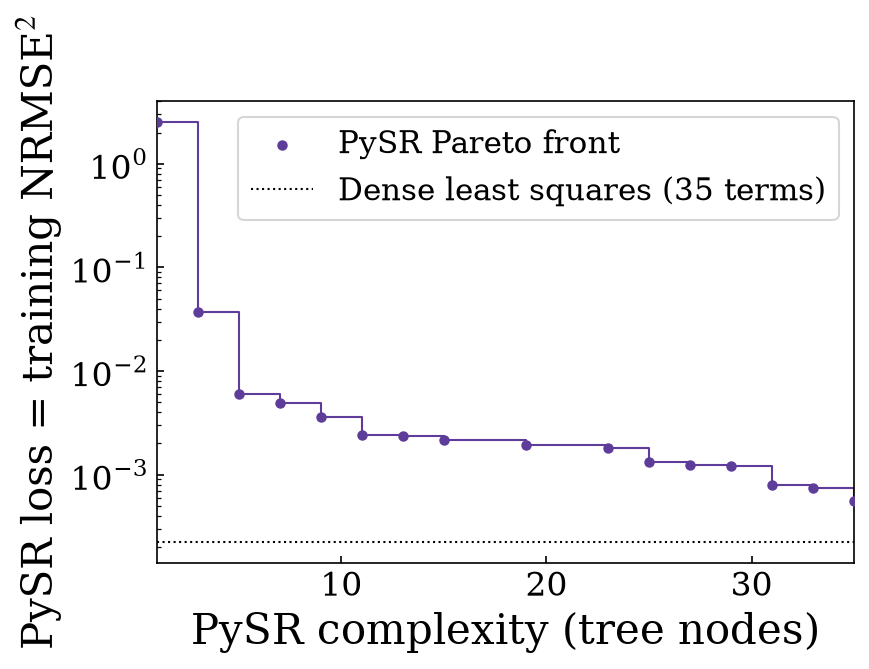

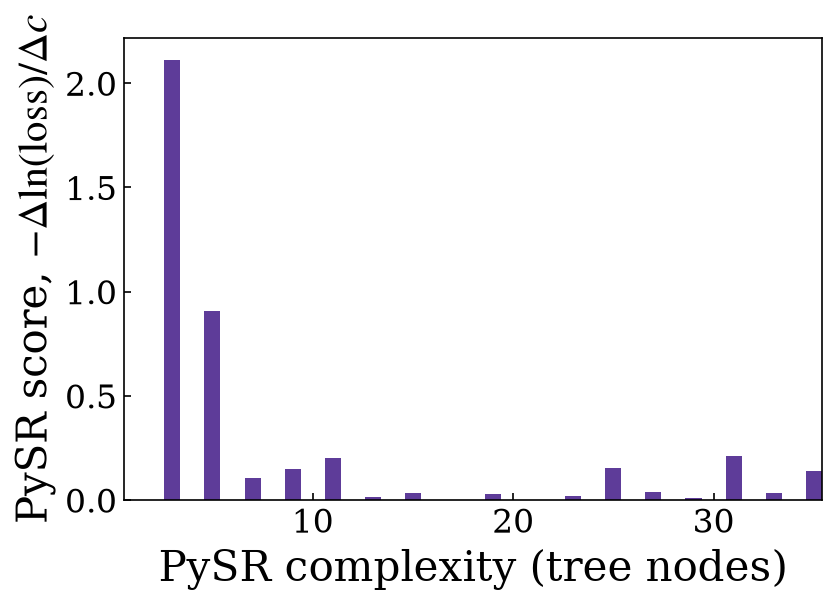

In [12]:
fig, ax = plt.subplots()
ax.step(final_front["complexity"], final_front["loss"], where="post", color=COLORS["purple"], lw=1.0)
ax.scatter(final_front["complexity"], final_front["loss"], s=16, color=COLORS["purple"], zorder=3,
           label="PySR Pareto front")
ax.axhline(EXPECTED_MINIMUM_LOSS, color="k", lw=1.0, ls=":",
           label=f"Dense least squares ({len(POLY_POWERS)} terms)")
ax.set_yscale("log")
ax.set(xlabel="PySR complexity (tree nodes)", ylabel="PySR loss = training NRMSE$^2$")
ax.legend()
fig.savefig(FIGURES_DIR / "pareto_front_loss.pdf")
plt.show()
plt.close(fig)

fig, ax = plt.subplots()
ax.bar(final_front["complexity"], final_front["pysr_score"], width=0.8, color=COLORS["purple"])
ax.set(xlabel="PySR complexity (tree nodes)", ylabel="PySR score, $-\\Delta\\ln(\\mathrm{loss})/\\Delta c$")
fig.savefig(FIGURES_DIR / "pareto_front_score.pdf")
plt.show()
plt.close(fig)

## 8. Selection

Common rule on the front: among the physically admissible equations, the one with the fewest polynomial terms within 10 % of the best training score. PySR's own `model_selection="best"` choice is shown for reference.

,choice,complexity,number_of_terms,training_NRMSE,training_score,structure
0,common rule (reported model),35,6,0.023695,0.022820,u + v + x + v^2 + x^2 + x^3
1,"PySR model_selection=""best"" (reference only)",31,6,0.028201,0.028334,u + v + x + v^2 + x^2 + x^3


Reference score (best admissible equation of the front): 0.02282; selection limit 0.02510. Dense least squares: 0.01463 (35 terms).
The selected PySR equation is outside 10 % of the dense least-squares score of the space.


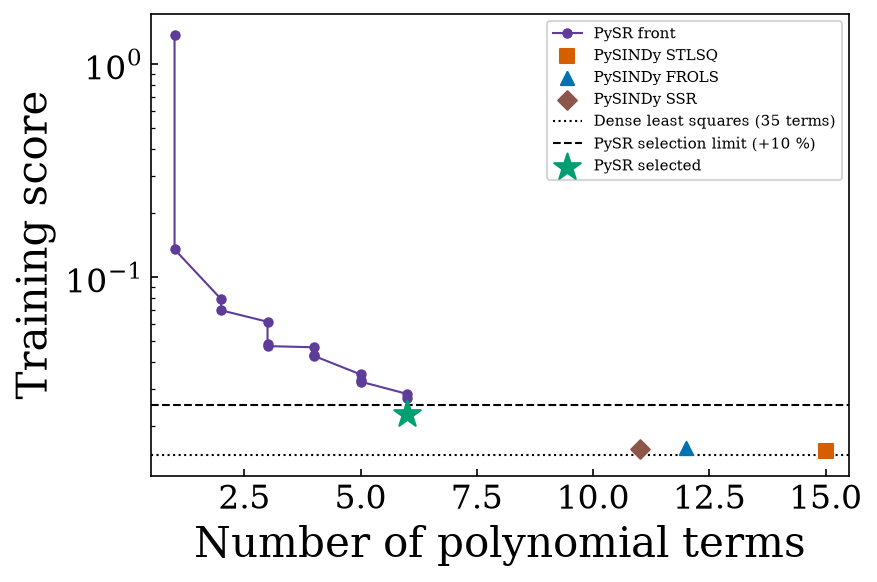

In [13]:
SELECTION_ORDER = ["number_of_terms", "training_score", "complexity"]


def select_common_rule(table):
    """Common rule on a front table: (selected row, reference score)."""
    admissible = table[table["physically_valid"].astype(bool)]
    if admissible.empty:
        raise RuntimeError("No equation of the PySR front passes the physical checks.")
    reference = float(admissible["training_score"].min())
    within = admissible[admissible["training_score"] <= reference * (1.0 + ACCEPTABLE_ERROR_INCREASE) + 1e-14]
    return within.sort_values(SELECTION_ORDER, kind="stable").iloc[0], reference


selected_row, reference_score = select_common_rule(final_front)
pysr_best_index = int(pysr_model.get_best().name)
pysr_best_row = final_front.set_index("equation_index").loc[pysr_best_index]
selection_rows = [
    {"choice": "common rule (reported model)", "complexity": int(selected_row["complexity"]),
     "number_of_terms": int(selected_row["number_of_terms"]), "training_NRMSE": selected_row["training_NRMSE"],
     "training_score": selected_row["training_score"], "structure": selected_row["structure"]},
    {"choice": 'PySR model_selection="best" (reference only)', "complexity": int(pysr_best_row["complexity"]),
     "number_of_terms": int(pysr_best_row["number_of_terms"]), "training_NRMSE": pysr_best_row["training_NRMSE"],
     "training_score": pysr_best_row["training_score"], "structure": pysr_best_row["structure"]},
]
display(pd.DataFrame(selection_rows))
print(f"Reference score (best admissible equation of the front): {reference_score:.5f}; selection limit "
      f"{reference_score * (1 + ACCEPTABLE_ERROR_INCREASE):.5f}. Dense least squares: "
      f"{DENSE_REFERENCE['training_score']:.5f} ({DENSE_REFERENCE['number_of_terms']:.0f} terms).")
within_dense = selected_row["training_score"] <= DENSE_REFERENCE["training_score"] * (1 + ACCEPTABLE_ERROR_INCREASE)
print("The selected PySR equation is " + ("within" if within_dense else "outside")
      + " 10 % of the dense least-squares score of the space.")

pysindy_train = PYSINDY_AGGREGATE[PYSINDY_AGGREGATE["role"] == "train"].set_index("model")
fig, ax = plt.subplots()
ax.plot(final_front["number_of_terms"], final_front["training_score"], "o-", color=COLORS["purple"], ms=4,
        lw=1.0, label="PySR front")
for (name, record), marker, color in zip(PYSINDY_MODELS.items(), ["s", "^", "D"],
                                         [COLORS["orange"], COLORS["blue"], COLORS["brown"]]):
    ax.scatter(record["number_of_terms"], pysindy_train.loc[name, "weighted_score"], marker=marker, s=40,
               color=color, zorder=3, label=f"PySINDy {name}")
ax.axhline(DENSE_REFERENCE["training_score"], color="k", lw=1.0, ls=":",
           label=f"Dense least squares ({len(POLY_POWERS)} terms)")
ax.axhline(reference_score * (1 + ACCEPTABLE_ERROR_INCREASE), color="k", lw=1.0, ls="--",
           label="PySR selection limit (+10 %)")
ax.scatter(selected_row["number_of_terms"], selected_row["training_score"], marker="*", s=180,
           color=COLORS["green"], zorder=4, label="PySR selected")
ax.set_yscale("log")
ax.set_xlim(0.5, max(final_front["number_of_terms"].max(),
                     max(r["number_of_terms"] for r in PYSINDY_MODELS.values())) + 0.5)
ax.set(xlabel="Number of polynomial terms", ylabel="Training score")
ax.legend(fontsize=7)
fig.savefig(FIGURES_DIR / "selection_vs_pysindy.pdf")
plt.show()
plt.close(fig)

## 9. Selected equation

Native tree, expansion in scaled and SI units, and term table.

In [14]:
selected_equation = selected_row["native_equation"]
selected_index = int(selected_row["equation_index"])
selected_analysis = _analysis_cache[selected_equation]
selected_terms = selected_analysis["terms"]
selected_expression = polynomial_expression(selected_terms)
selected_function = lambda x_values, v_values, u_values: polynomial_prediction(selected_terms, x_values, v_values, u_values)

print("1. Native PySR tree (scaled variables x/sx, v/sv, u/su; target v_dot/s_vdot):")
print("   ", selected_equation)
print("2. Expanded in scaled variables:")
print("    v_dot/s_vdot =", polynomial_expression(selected_analysis["scaled_terms"], 6))
print("3. Expanded in SI units (reported model):")
print("    x_dot = v   (imposed kinematic definition)")
print("    v_dot =", polynomial_expression(selected_terms, 8))
display(Markdown(r"$$\dot v = " + sp.latex(polynomial_expression(selected_terms, 4)) + "$$"))

pysindy_coefficients = {name: {(a, b, c): coefficient for coefficient, a, b, c in record["terms"]}
                        for name, record in PYSINDY_MODELS.items()}
term_rows = []
for (coefficient, a, b, c), (scaled_coefficient, *_) in zip(selected_terms, selected_analysis["scaled_terms"]):
    contribution = coefficient * X_train[:, 0]**a * X_train[:, 1]**b * X_train[:, 2]**c
    term_rows.append({"term": monomial_name(a, b, c), "coefficient_SI": coefficient,
                      "scaled_coefficient": scaled_coefficient,
                      "RMS_contribution_over_target_std": float(np.sqrt(np.mean(contribution**2)) / target_scale),
                      **{f"PySINDy_{name}_SI": coefficients.get((a, b, c), np.nan)
                         for name, coefficients in pysindy_coefficients.items()}})
term_contributions = pd.DataFrame(term_rows)
display(term_contributions)
print("RMS contributions of different terms can overlap or cancel; they are not explained-variance fractions.")

selected_diagnostics = physical_diagnostics(selected_terms)
physical_table = pd.DataFrame(
    [{"model": "PySR (selected)", "number_of_terms": len(selected_terms), **selected_diagnostics}]
    + [{"model": f"PySINDy {name}", "number_of_terms": record["number_of_terms"], **record["diagnostics"]}
       for name, record in PYSINDY_MODELS.items()])
display(physical_table[["model", "number_of_terms", "physically_valid", "has_state_nonlinearity",
                        "linear_natural_frequency_hz", "linear_damping_ratio"]])

# Text summary of the selected equation.
coefficient = {(a, b, c): value for value, a, b, c in selected_terms}
lines = [f"* {len(selected_terms)} polynomial terms (PySINDy: "
         + ", ".join(f"{name} {record['number_of_terms']}" for name, record in PYSINDY_MODELS.items()) + ").",
         f"* Linear oscillator: natural frequency {selected_diagnostics['linear_natural_frequency_hz']:.2f} Hz, "
         f"damping ratio {selected_diagnostics['linear_damping_ratio']:.4f}; input gain {coefficient.get((0, 0, 1), np.nan):.4f} "
         "(the kinematics imply -1, see README, Known limitations 3)."]
if (3, 0, 0) in coefficient:
    softening = np.sign(coefficient[(3, 0, 0)]) != np.sign(coefficient[(1, 0, 0)])
    lines.append(f"* Cubic stiffness x^3 with coefficient {coefficient[(3, 0, 0)]:.3e}: "
                 + ("opposite in sign to the linear restoring term, so on its own it softens the spring as the amplitude grows"
                    if softening else "same sign as the linear restoring term, so on its own it hardens the spring")
                 + " (the even x^2 term also shifts the effective stiffness).")
if (2, 0, 0) in coefficient and (0, 2, 0) in coefficient:
    ratio = -coefficient[(2, 0, 0)] / coefficient[(0, 2, 0)]
    lines.append(f"* x^2 and v^2 appear as a pair: -c(x^2)/c(v^2) = {ratio:.4g} s^-2 against the linear stiffness "
                 f"-c(x) = {-coefficient[(1, 0, 0)]:.4g} s^-2. They cancel at zero frequency and reproduce a second "
                 "harmonic of the high-pass filtered target; v^2 is not nonlinear damping (README, Known limitations 4).")
display(Markdown("\n".join(lines)))

1. Native PySR tree (scaled variables x/sx, v/sv, u/su; target v_dot/s_vdot):
    ((((((x - ((-0.17820723 - v) * (v * -0.16333503))) - (-0.16704305 * ((x - ((x * x) * -0.23410675)) * x))) - v) * 0.04988812) + u) - (1.192983 * u)) + (x * -1.0466506)
2. Expanded in scaled variables:
    v_dot/s_vdot = -0.192983*u - 0.00814848*v**2 - 0.0513402*v + 0.00195092*x**3 + 0.00833346*x**2 - 0.996763*x
3. Expanded in SI units (reported model):
    x_dot = v   (imposed kinematic definition)
    v_dot = -1.0580576*u - 45.898673*v**2 - 30.917379*v + 2.1211809e+10*x**3 + 16392291.0*x**2 - 354716.76*x


$$\dot v = - 1.058 u - 45.9 v^{2} - 30.92 v + 2.121 \cdot 10^{10} x^{3} + 1.639 \cdot 10^{7} x^{2} - 3.547 \cdot 10^{5} x$$

,term,coefficient_SI,scaled_coefficient,RMS_contribution_over_target_std,PySINDy_STLSQ_SI,PySINDy_FROLS_SI,PySINDy_SSR_SI
0,u,-1.058058e+00,-0.192983,0.192983,-1.057632e+00,-1.060837e+00,-1.060579e+00
1,v,-3.091738e+01,-0.051340,0.051340,-2.651632e+01,-2.806789e+01,-2.802869e+01
2,x,-3.547168e+05,-0.996762,0.996762,-3.620087e+05,-3.612146e+05,-3.599690e+05
3,v^2,-4.589867e+01,-0.008148,0.031404,-3.166076e+01,-3.093900e+01,-4.268505e+01
4,x^2,1.639229e+07,0.008333,0.032845,1.398070e+07,1.199685e+07,1.468456e+07
5,x^3,2.121181e+10,0.001951,0.040054,5.042182e+10,5.158567e+10,4.378218e+10


RMS contributions of different terms can overlap or cancel; they are not explained-variance fractions.


,model,number_of_terms,physically_valid,has_state_nonlinearity,linear_natural_frequency_hz,linear_damping_ratio
0,PySR (selected),6,True,True,94.789664,0.025956
1,PySINDy STLSQ,15,True,True,95.759002,0.022036
2,PySINDy FROLS,12,True,True,95.653918,0.023351
3,PySINDy SSR,11,True,True,95.488855,0.023358


* 6 polynomial terms (PySINDy: STLSQ 15, FROLS 12, SSR 11).
* Linear oscillator: natural frequency 94.79 Hz, damping ratio 0.0260; input gain -1.0581 (the kinematics imply -1, see README, Known limitations 3).
* Cubic stiffness x^3 with coefficient 2.121e+10: opposite in sign to the linear restoring term, so on its own it softens the spring as the amplitude grows (the even x^2 term also shifts the effective stiffness).
* x^2 and v^2 appear as a pair: -c(x^2)/c(v^2) = 3.571e+05 s^-2 against the linear stiffness -c(x) = 3.547e+05 s^-2. They cancel at zero frequency and reproduce a second harmonic of the high-pass filtered target; v^2 is not nonlinear damping (README, Known limitations 4).

## 10. Convergence

The common rule is applied to the front after every block; the budget is flagged as short if the selected structure changed in the last three blocks.

,iterations,front_size,lowest_loss,best_training_score,selected_structure,selected_terms,selected_complexity,selected_training_score,elapsed_minutes
0,10,11,0.001958,0.043288,u + v + x + x^2,4,33,0.043288,1.086730
1,20,17,0.001171,0.032567,u + v + x + v*u + x^2 + x^2*v + x^3,7,39,0.032567,2.209851
2,30,13,0.000606,0.023094,u + v + x + v^2 + x^2 + x^3,6,37,0.023094,3.260809
3,40,14,0.000606,0.023094,u + v + x + v^2 + x^2 + x^3,6,37,0.023094,4.366671
4,50,16,0.000576,0.022705,u + v + x + v^2 + x^2 + x^3,6,37,0.022705,5.364779
5,60,16,0.000561,0.022820,u + v + x + v^2 + x^2 + x^3,6,35,0.022820,6.550208
6,70,16,0.000561,0.022820,u + v + x + v^2 + x^2 + x^3,6,35,0.022820,7.685868
7,80,17,0.000561,0.022820,u + v + x + v^2 + x^2 + x^3,6,35,0.022820,8.560916
8,90,17,0.000561,0.022820,u + v + x + v^2 + x^2 + x^3,6,35,0.022820,9.675242
9,100,16,0.000561,0.022820,u + v + x + v^2 + x^2 + x^3,6,35,0.022820,10.729804


The selected structure is unchanged over the last 8 block(s) (80 iterations).


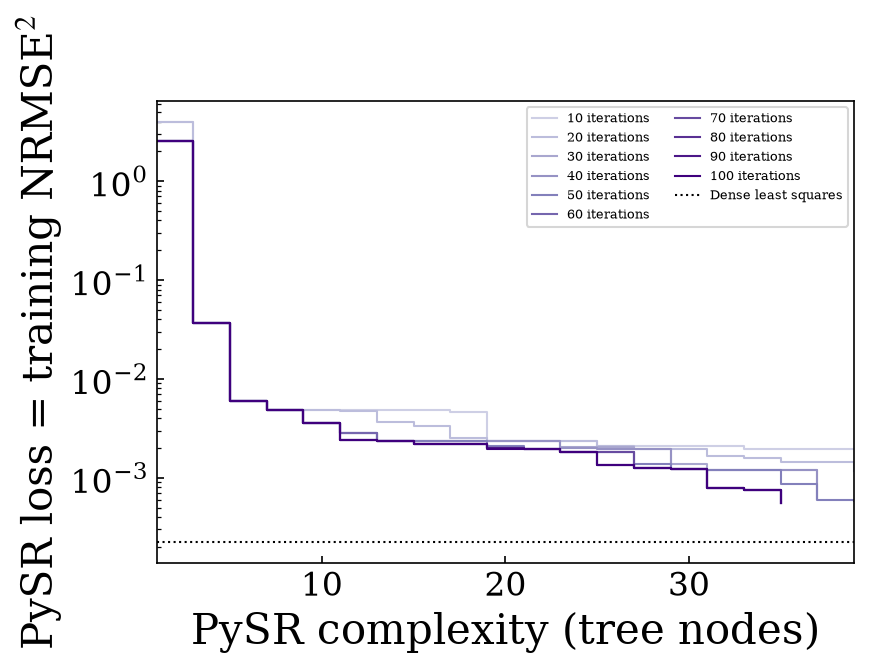

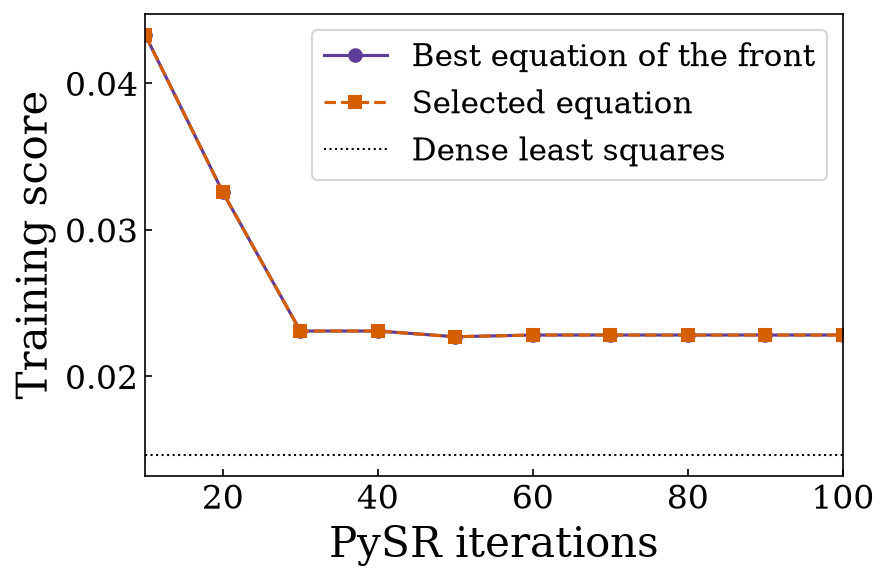

In [15]:
history_rows = []
for front in block_fronts:
    equations = front.set_index(pd.RangeIndex(len(front)))
    table = front_table(equations, lambda i, equations=equations: sp.sympify(
        sp.parse_expr(equations.loc[i, "equation"], local_dict={"x": x, "v": v, "u": u})))
    row, reference = select_common_rule(table)
    history_rows.append({"iterations": int(front["iterations"].iloc[0]), "front_size": len(table),
                         "lowest_loss": float(table["loss"].min()),
                         "best_training_score": reference, "selected_structure": row["structure"],
                         "selected_terms": int(row["number_of_terms"]), "selected_complexity": int(row["complexity"]),
                         "selected_training_score": float(row["training_score"])})
search_history = pd.DataFrame(history_rows)
search_history["elapsed_minutes"] = np.cumsum(block_times) / 60
if search_history["selected_structure"].iloc[-1] != selected_row["structure"]:
    raise RuntimeError("The last block does not reproduce the final selection.")
unchanged = search_history["selected_structure"] == search_history["selected_structure"].iloc[-1]
stable_blocks = int(len(unchanged) - np.flatnonzero(~unchanged.to_numpy())[-1] - 1) if (~unchanged).any() else len(unchanged)
display(search_history)
print(f"The selected structure is unchanged over the last {stable_blocks} block(s) "
      f"({stable_blocks * ITERATIONS_PER_BLOCK} iterations).")
if stable_blocks < 3:
    print("WARNING: the selection changed within the last 30 iterations; the budget may be short.")

fig, ax = plt.subplots()
shades = plt.cm.Purples(np.linspace(0.3, 1.0, len(block_fronts)))
for front, shade in zip(block_fronts, shades):
    finite = front[np.isfinite(front["loss"])]
    ax.step(finite["complexity"], finite["loss"], where="post", color=shade, lw=1.0,
            label=f"{int(front['iterations'].iloc[0])} iterations")
ax.axhline(EXPECTED_MINIMUM_LOSS, color="k", lw=1.0, ls=":", label="Dense least squares")
ax.set_yscale("log")
ax.set(xlabel="PySR complexity (tree nodes)", ylabel="PySR loss = training NRMSE$^2$")
ax.legend(fontsize=6, ncol=2)
fig.savefig(FIGURES_DIR / "search_convergence_fronts.pdf")
plt.show()
plt.close(fig)

fig, ax = plt.subplots()
ax.plot(search_history["iterations"], search_history["best_training_score"], "o-", label="Best equation of the front")
ax.plot(search_history["iterations"], search_history["selected_training_score"], "s--", label="Selected equation")
ax.axhline(DENSE_REFERENCE["training_score"], color="k", lw=1.0, ls=":", label="Dense least squares")
ax.set(xlabel="PySR iterations", ylabel="Training score")
ax.legend()
fig.savefig(FIGURES_DIR / "search_convergence_score.pdf")
plt.show()
plt.close(fig)

## 11. Train and test results

One-step prediction at the measured states of every experiment, next to the saved PySINDy results.

,signal,level_mg,sweep,model,role,total_RMSE,total_NRMSE,total_R2,resonance_NRMSE,weighted_score
0,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,down,PySR,train,0.506474,0.023535,0.999446,0.020268,0.021248
1,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,up,PySR,train,0.512063,0.024647,0.999393,0.021546,0.022476
2,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,down,PySR,train,0.880292,0.022075,0.999513,0.021386,0.021592
3,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,up,PySR,train,0.778473,0.020305,0.999588,0.019846,0.019984
4,relative_acceleration_000mA_1500mg_50-150_Hz_s...,1500,down,PySR,test,1.480525,0.024662,0.999392,0.024379,0.024464
5,relative_acceleration_000mA_1500mg_50-150_Hz_s...,1500,up,PySR,test,1.657161,0.028939,0.999163,0.028943,0.028942
6,relative_acceleration_000mA_2000mg_50-150_Hz_s...,2000,down,PySR,train,1.927438,0.024827,0.999384,0.024838,0.024835
7,relative_acceleration_000mA_2000mg_50-150_Hz_s...,2000,up,PySR,train,2.122103,0.028445,0.999191,0.028894,0.028759
8,relative_acceleration_000mA_2500mg_50-150_Hz_s...,2500,down,PySR,train,2.042877,0.021822,0.999524,0.019030,0.019867
9,relative_acceleration_000mA_2500mg_50-150_Hz_s...,2500,up,PySR,train,2.080156,0.022113,0.999511,0.019744,0.020455


,level_mg,role,model,signals,samples,total_RMSE,total_NRMSE,total_R2,resonance_NRMSE,weighted_score
0,500,train,PySR,2,802816,0.509276,0.024078,0.999420,0.020892,0.021848
1,1000,train,PySR,2,802753,0.830943,0.021243,0.999549,0.020662,0.020837
2,1500,test,PySR,2,802753,1.571327,0.026785,0.999283,0.026644,0.026686
3,2000,train,PySR,2,802816,2.027109,0.026625,0.999291,0.026856,0.026787
4,2500,train,PySR,2,802753,2.061600,0.021969,0.999517,0.019392,0.020165


,model,role,levels_mg,signals,samples,total_RMSE,total_NRMSE,total_R2,resonance_NRMSE,weighted_score
0,PySR,train,"(500, 1000, 2000, 2500)",8,3211138,1.525547,0.023695,0.999439,0.022445,0.022820
1,PySR,test,"(1500,)",2,802753,1.571327,0.026785,0.999283,0.026644,0.026686


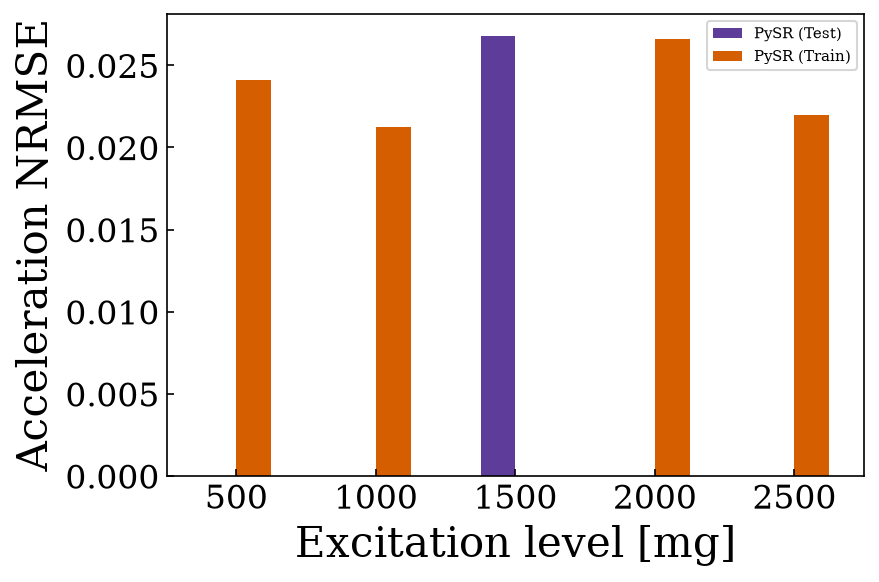

,model,number_of_terms,train_total_NRMSE,train_resonance_NRMSE,train_weighted_score,test_total_NRMSE,test_resonance_NRMSE,test_weighted_score
0,PySR,6,0.023695,0.022445,0.022820,0.026785,0.026644,0.026686
1,PySINDy STLSQ,15,0.015598,0.015146,0.015282,0.017481,0.017495,0.017491
2,PySINDy FROLS,12,0.016295,0.015685,0.015868,0.018920,0.018907,0.018911
3,PySINDy SSR,11,0.016319,0.015407,0.015681,0.017355,0.017076,0.017159


On the held-out 1500 mg level PySR reaches a test NRMSE of 0.0268 with 6 terms; the best PySINDy model on this level, PySINDy SSR, reaches 0.0174 with 11 terms. The PySR error is 1.54 times larger, with 1.8 times fewer terms. Train and test errors are within 25 % of each other for every model (0.0237 train vs 0.0268 test for PySR): no model degrades markedly on the held-out level.

In [16]:
one_step_series = build_series(all_signals)
add_predictions(one_step_series, {"PySR": selected_function})
one_step_metrics, one_step_per_level, one_step_aggregate = summarize_models(one_step_series)
display(one_step_metrics)
display(one_step_per_level)
display(one_step_aggregate)
plot_level_metrics(one_step_per_level, "total_NRMSE", "Acceleration NRMSE", FIGURES_DIR / "one_step_level_metrics.pdf")

comparison_rows = []
for model, aggregate, n_terms in ([("PySR", one_step_aggregate, len(selected_terms))]
                                  + [(name, PYSINDY_AGGREGATE, record["number_of_terms"])
                                     for name, record in PYSINDY_MODELS.items()]):
    rows = aggregate[aggregate["model"] == model].set_index("role")
    comparison_rows.append({"model": model if model == "PySR" else f"PySINDy {model}", "number_of_terms": n_terms,
                            **{f"{role}_{metric}": rows.loc[role, metric] for role in ROLES
                               for metric in ["total_NRMSE", "resonance_NRMSE", "weighted_score"]}})
comparison_with_pysindy = pd.DataFrame(comparison_rows)
display(comparison_with_pysindy)
pysr_row = comparison_with_pysindy.iloc[0]
best_pysindy = comparison_with_pysindy.iloc[1:].sort_values("test_total_NRMSE").iloc[0]
display(Markdown(
    f"On the held-out 1500 mg level PySR reaches a test NRMSE of {pysr_row['test_total_NRMSE']:.4f} with "
    f"{pysr_row['number_of_terms']} terms; the best PySINDy model on this level, {best_pysindy['model']}, reaches "
    f"{best_pysindy['test_total_NRMSE']:.4f} with {best_pysindy['number_of_terms']} terms. The PySR error is "
    f"{pysr_row['test_total_NRMSE'] / best_pysindy['test_total_NRMSE']:.2f} times larger, with "
    f"{best_pysindy['number_of_terms'] / pysr_row['number_of_terms']:.1f} times fewer terms. "
    + ("Train and test errors are within 25 % of each other for every model "
       f"({pysr_row['train_total_NRMSE']:.4f} train vs {pysr_row['test_total_NRMSE']:.4f} test for PySR): "
       "no model degrades markedly on the held-out level."
       if bool((abs(comparison_with_pysindy["test_total_NRMSE"] / comparison_with_pysindy["train_total_NRMSE"] - 1)
                < 0.25).all())
       else "At least one model degrades by more than 25 % from train to test; see the table above.")))

## 12. Diagnostic figures

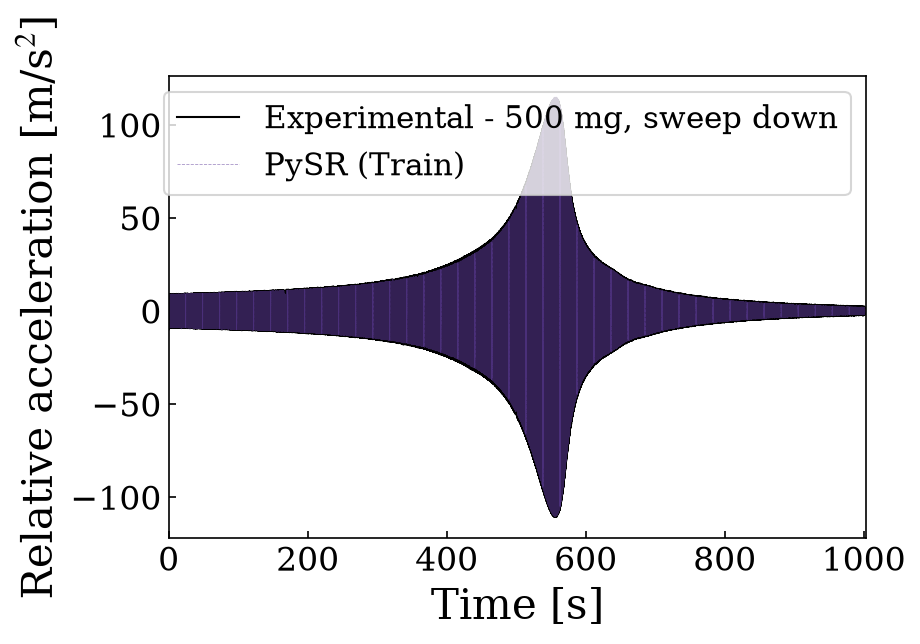

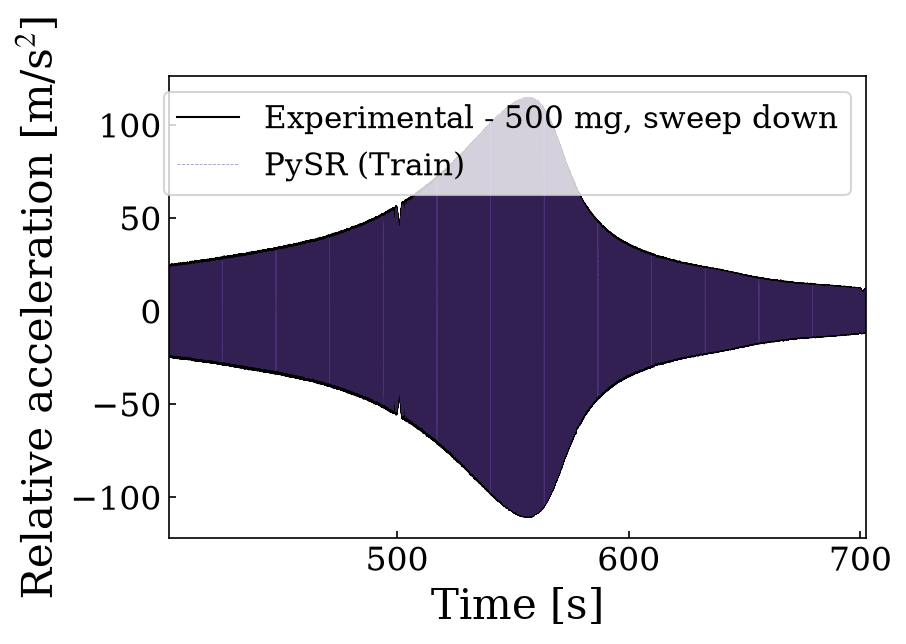

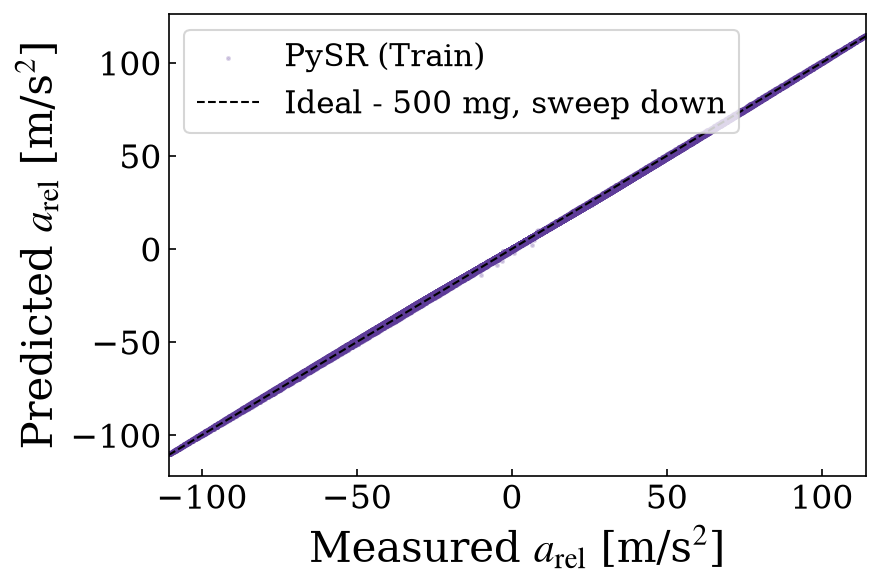

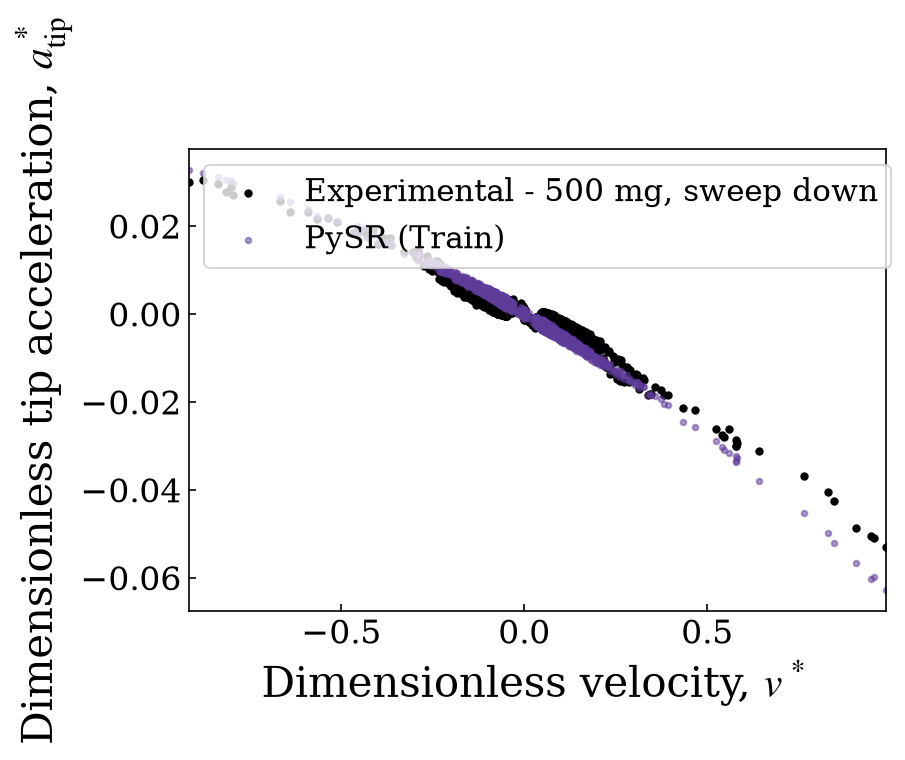

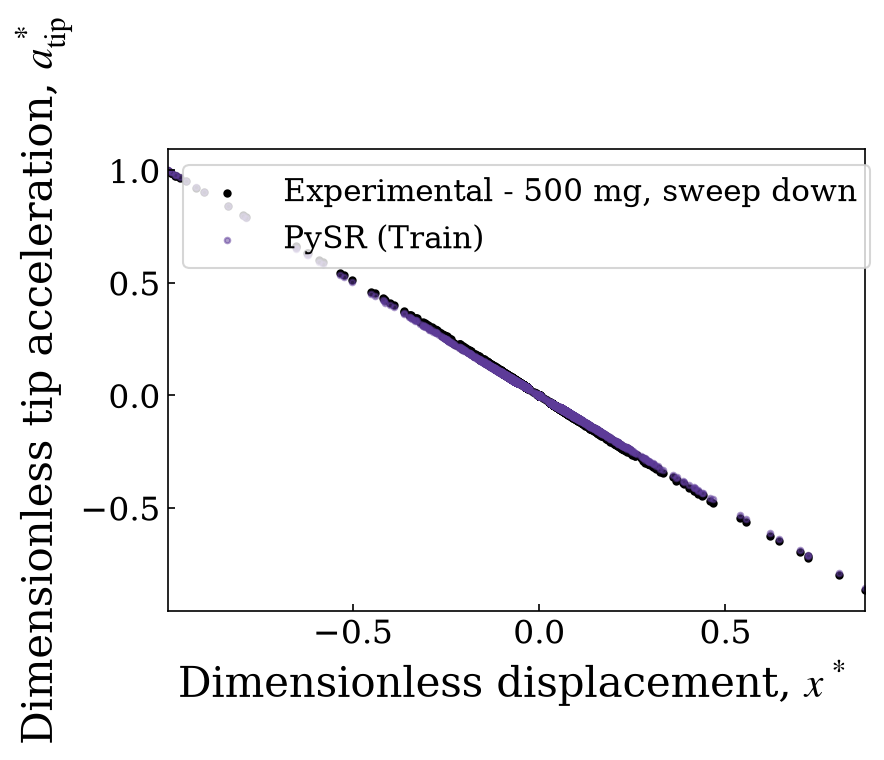

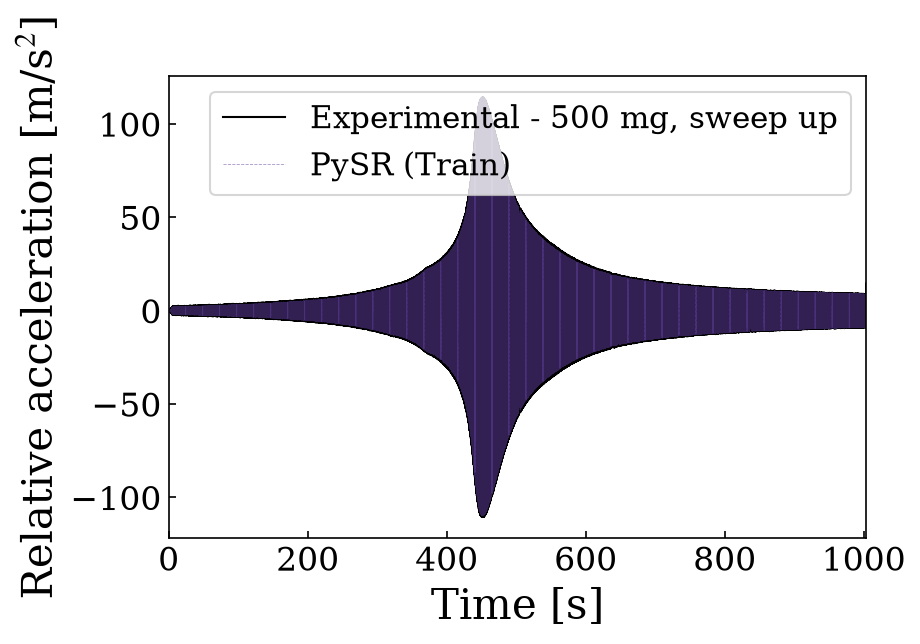

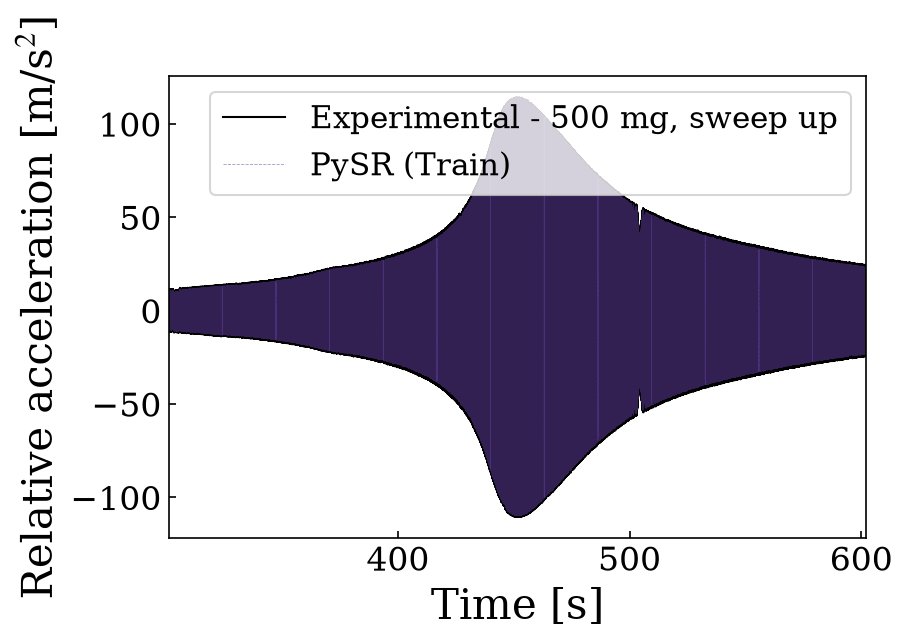

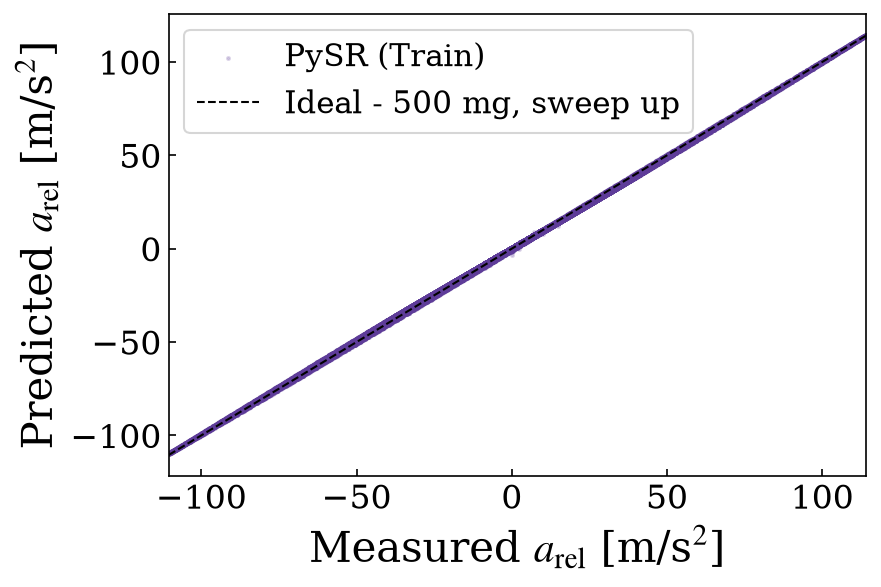

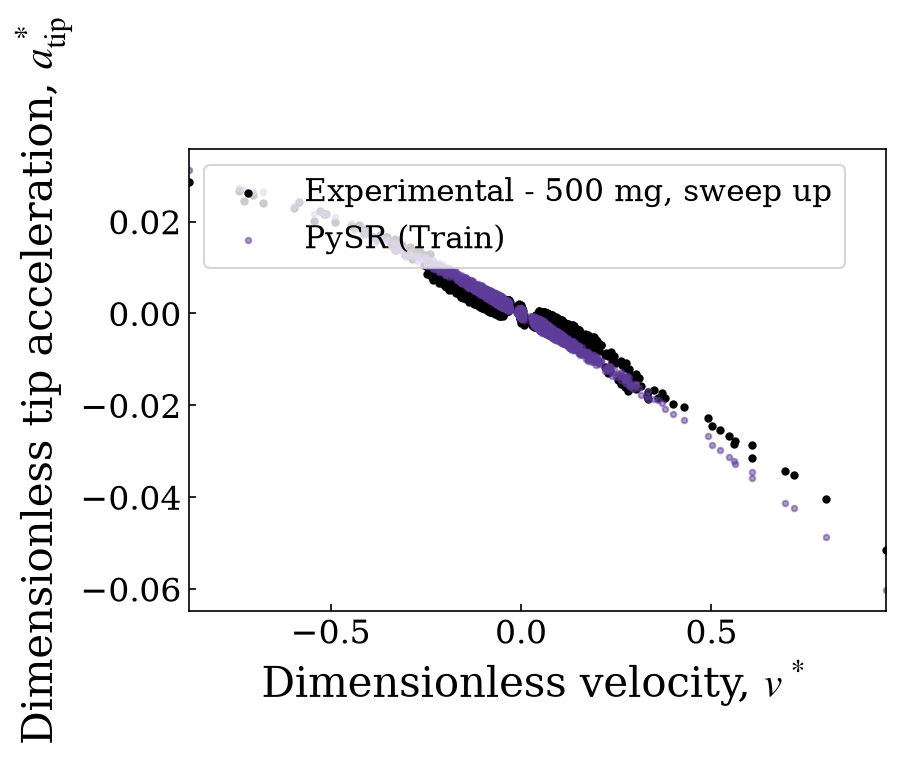

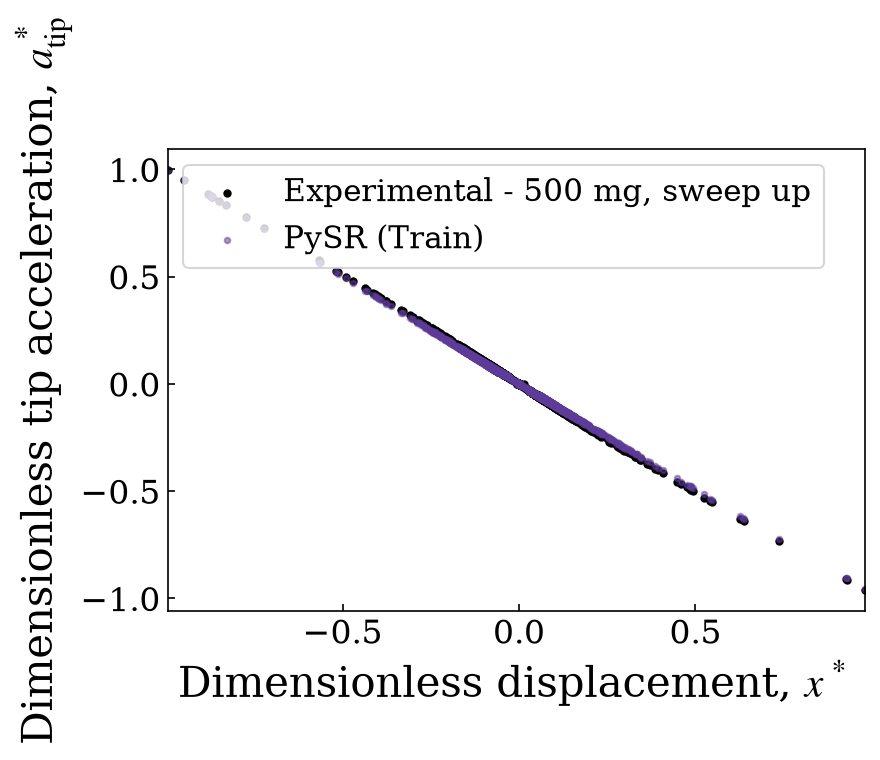

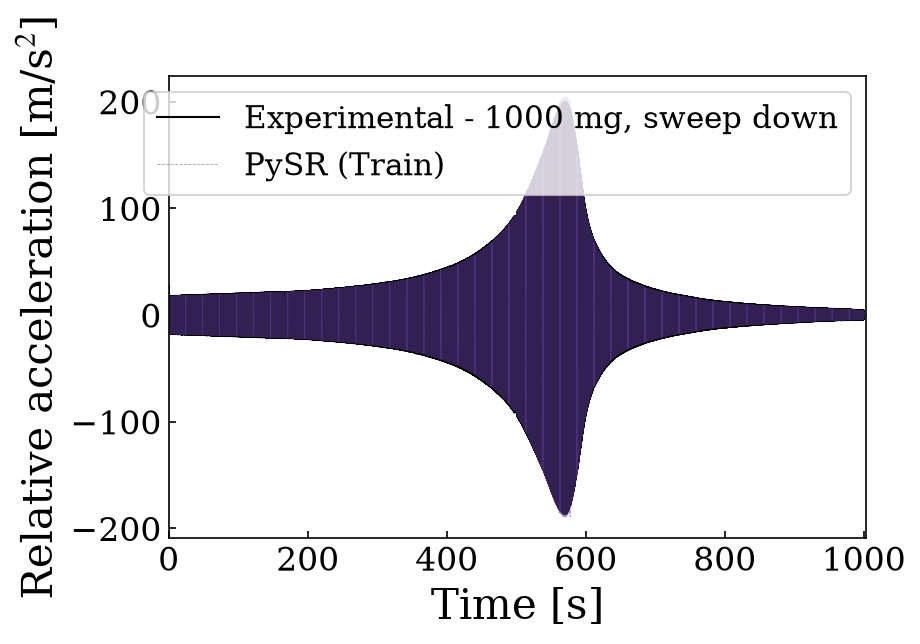

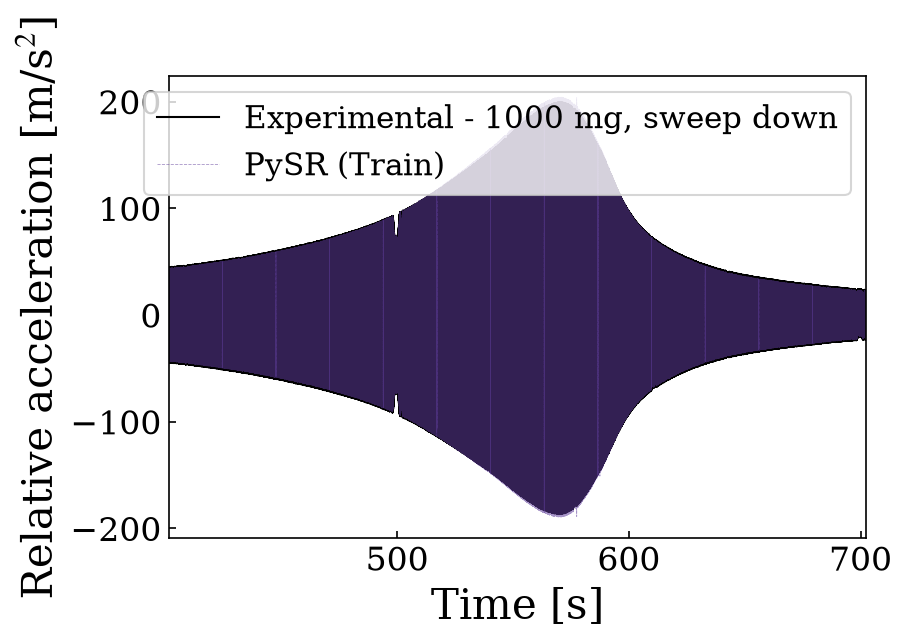

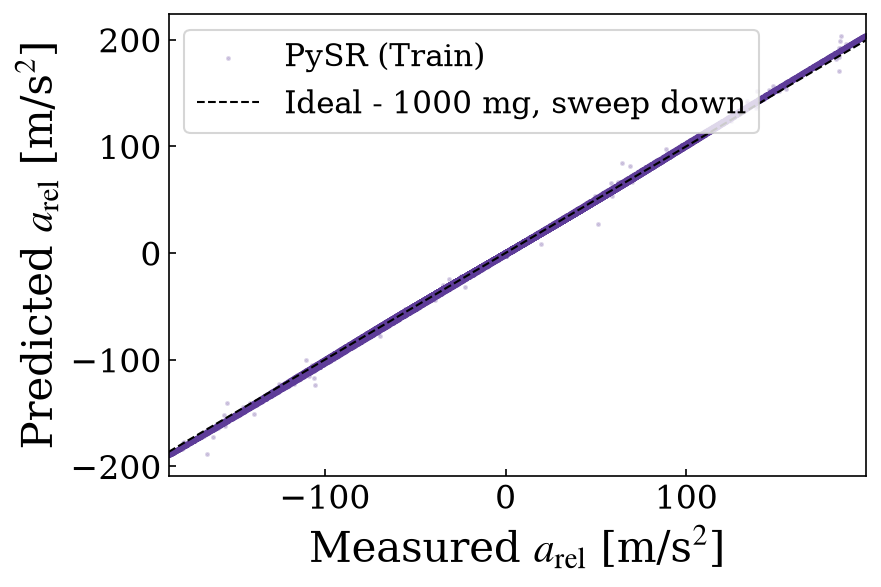

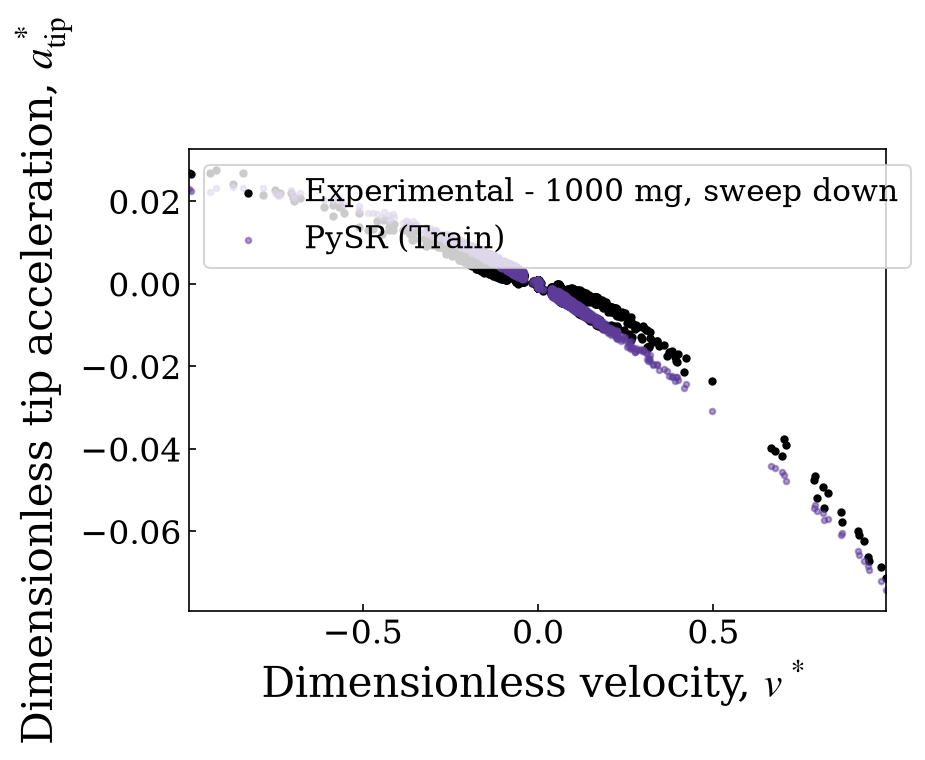

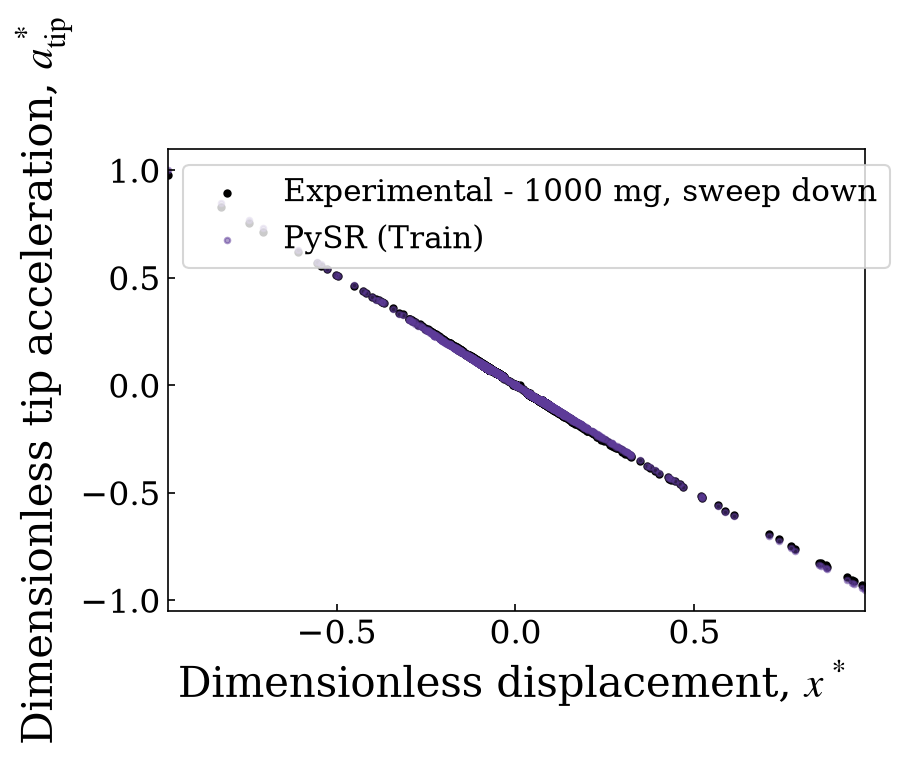

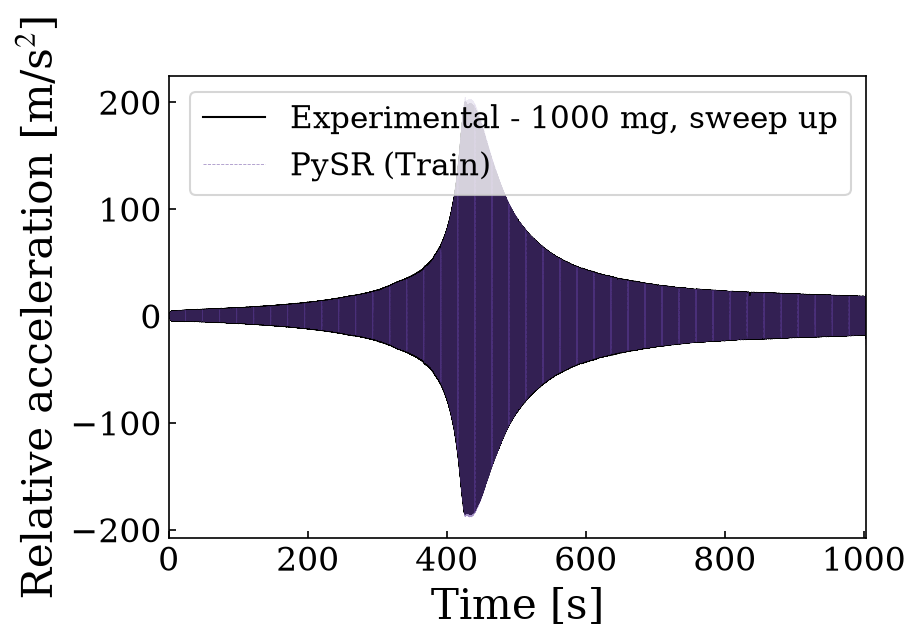

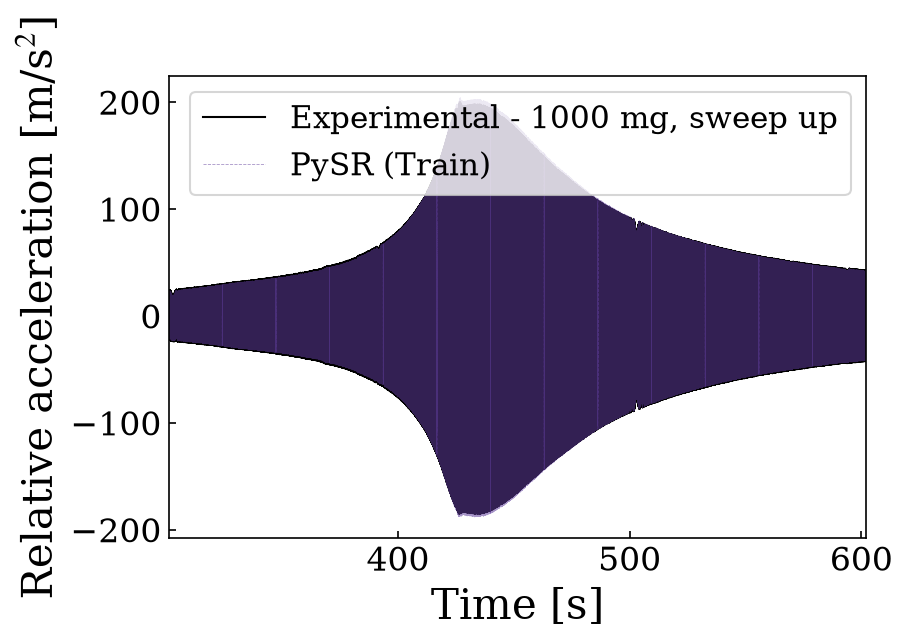

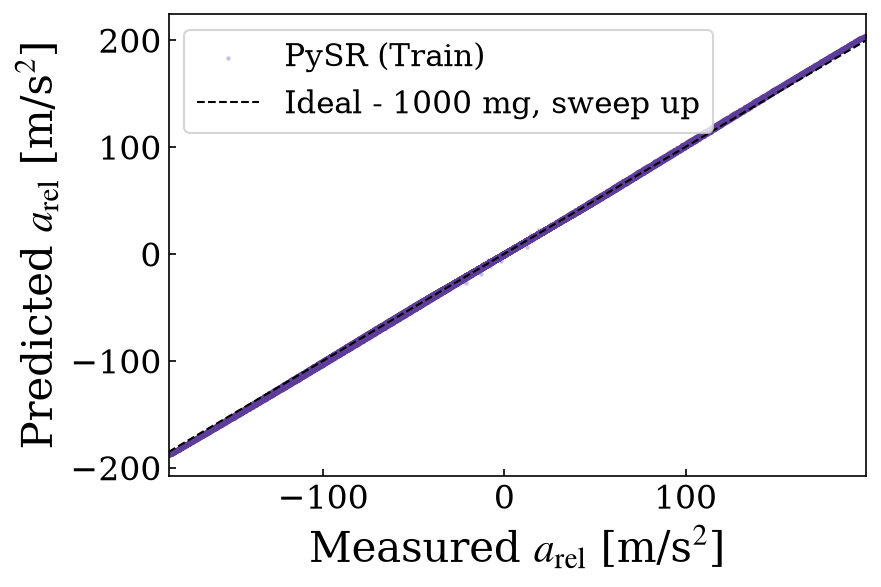

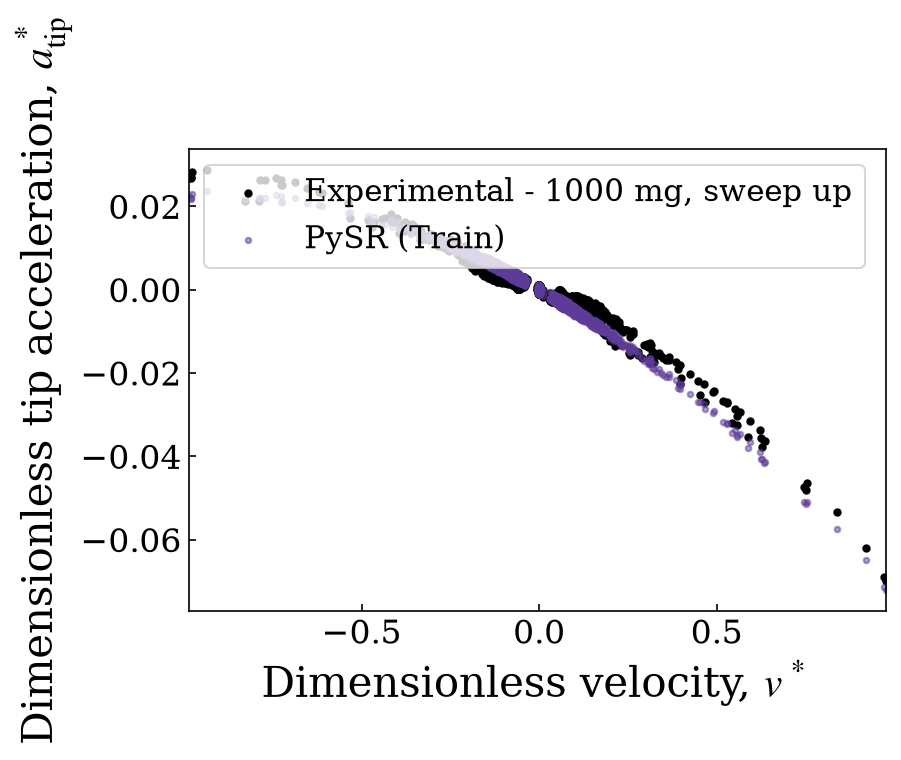

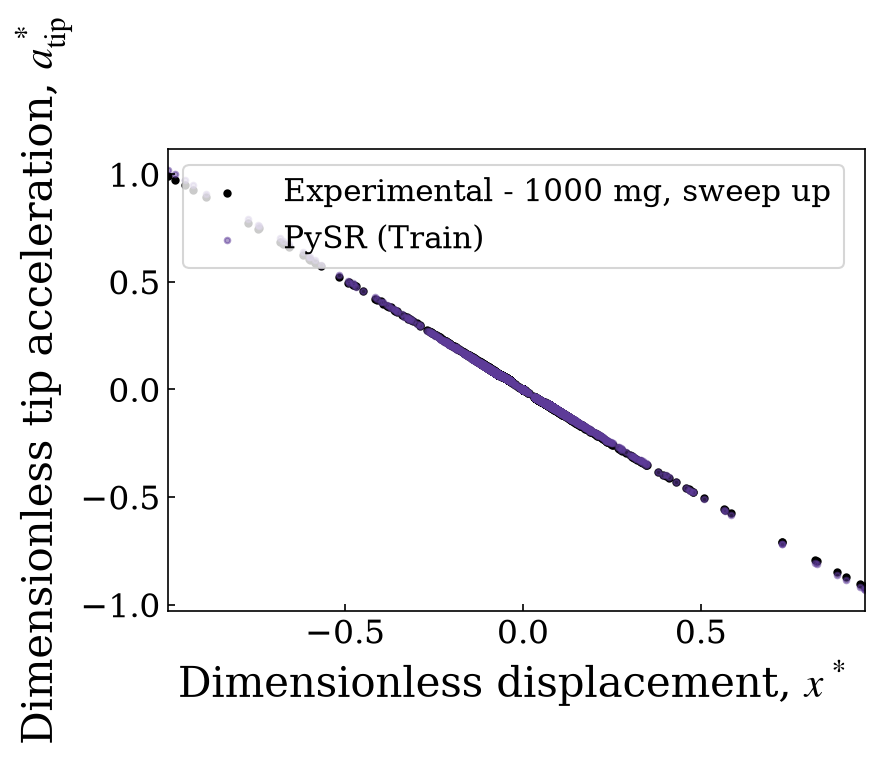

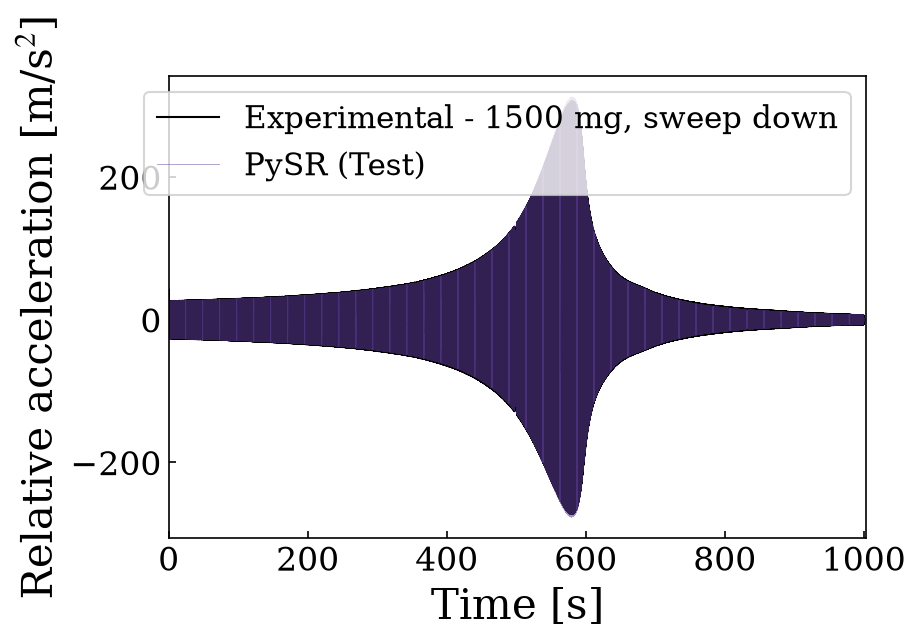

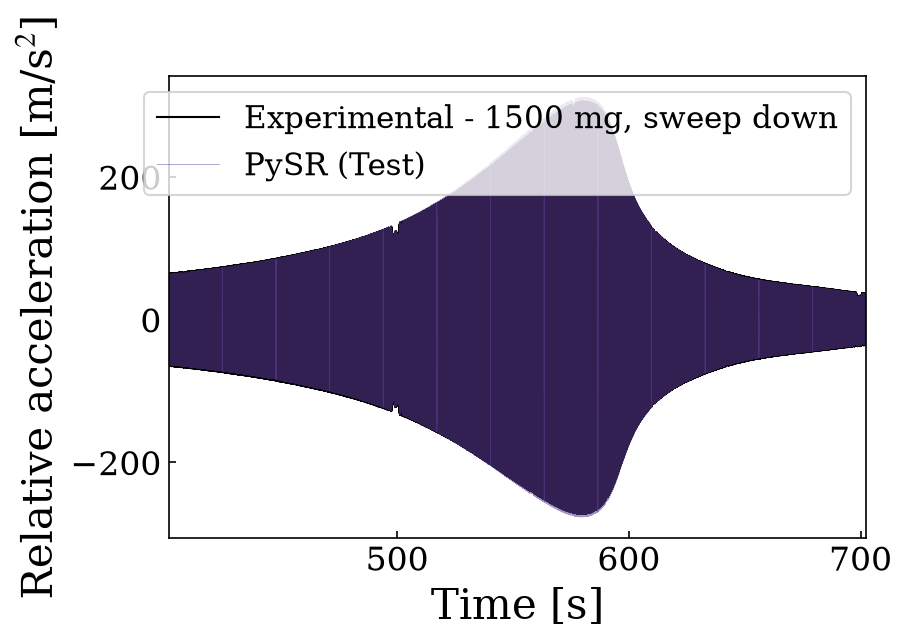

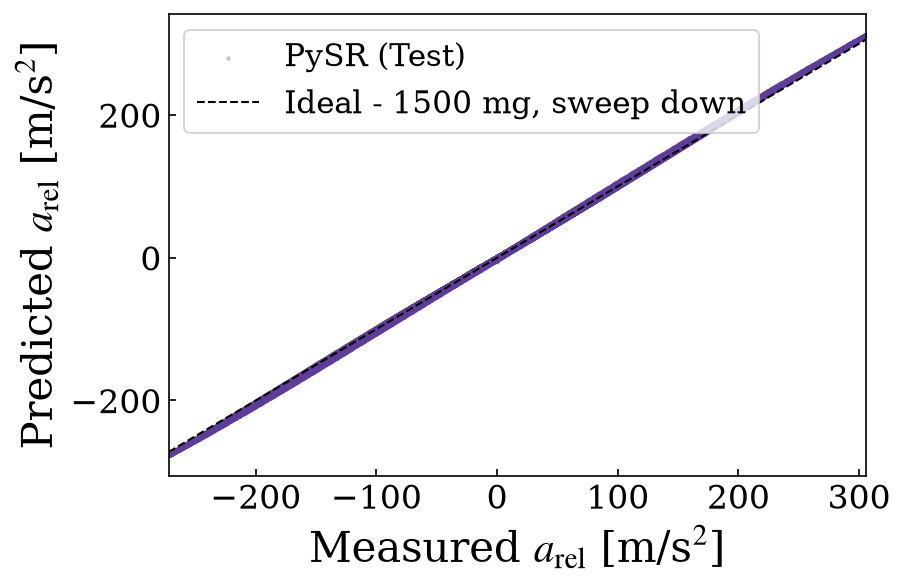

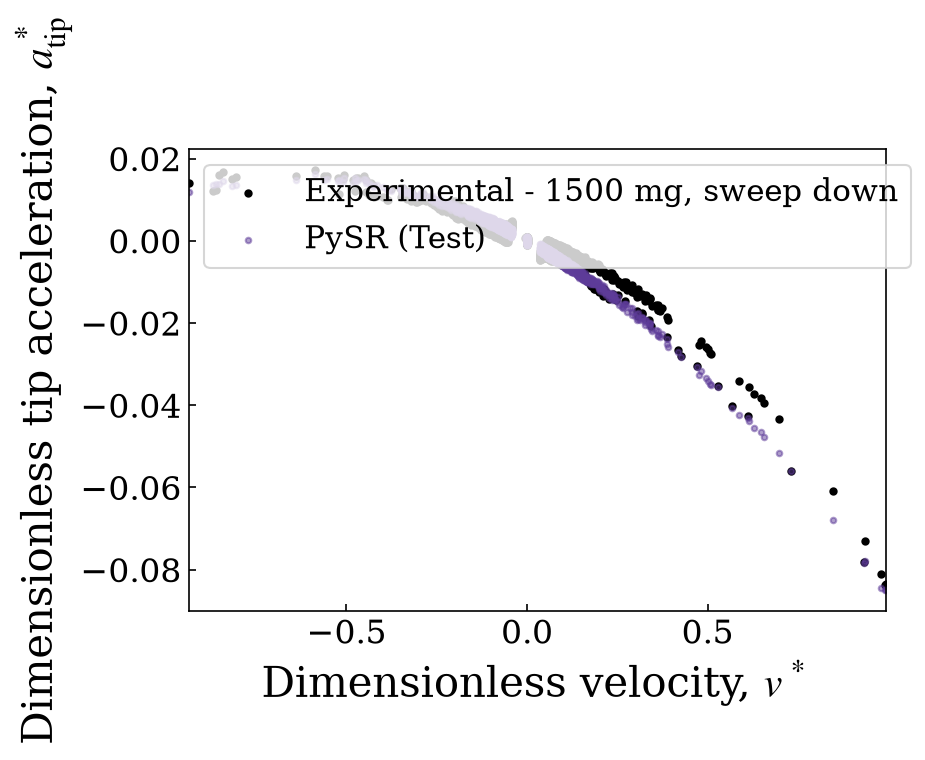

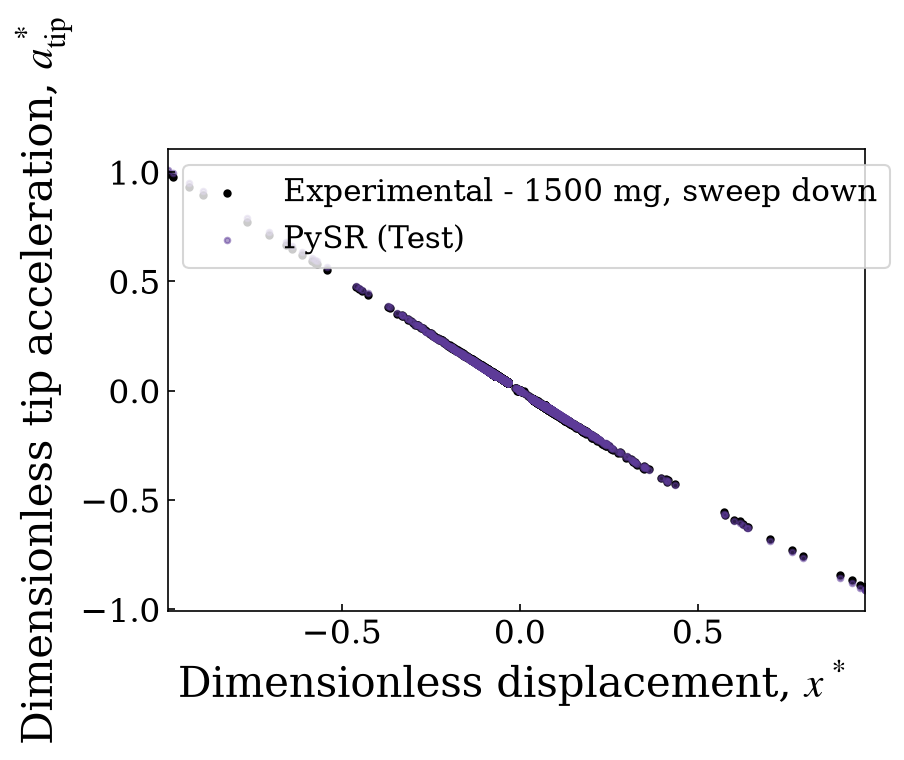

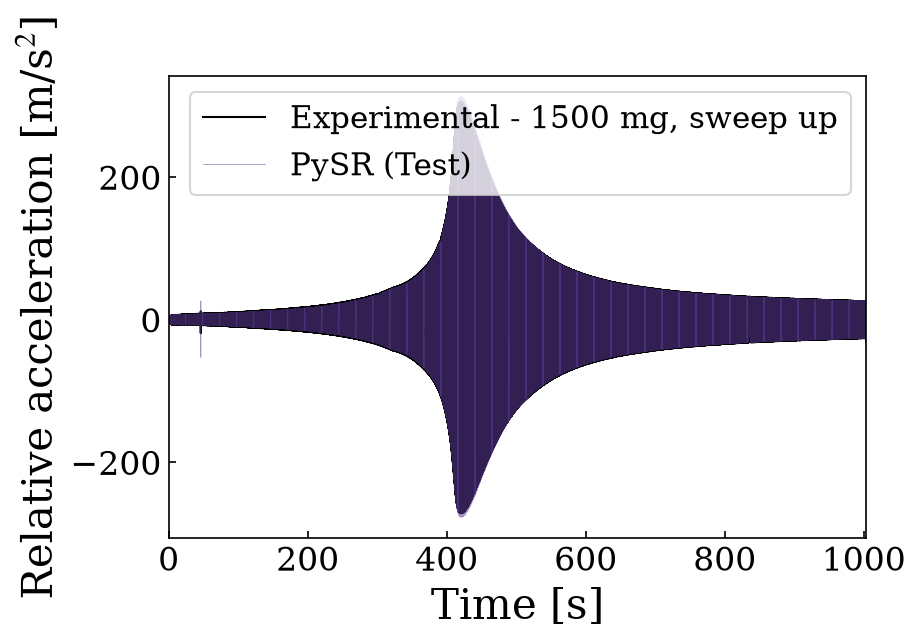

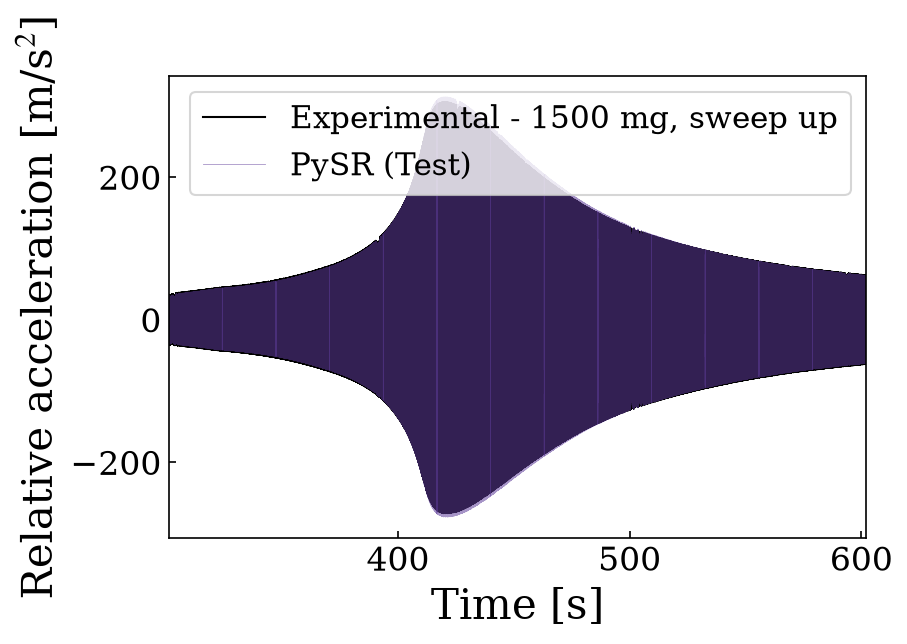

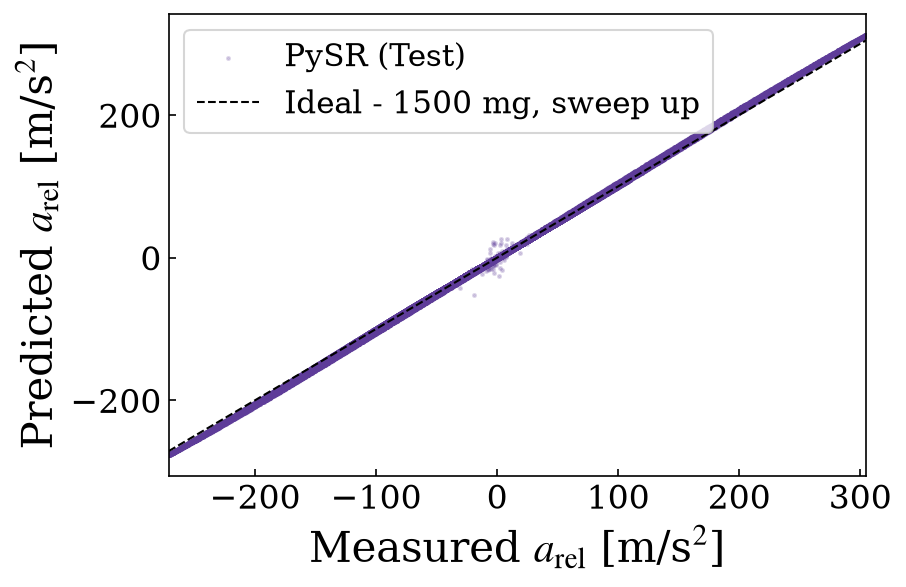

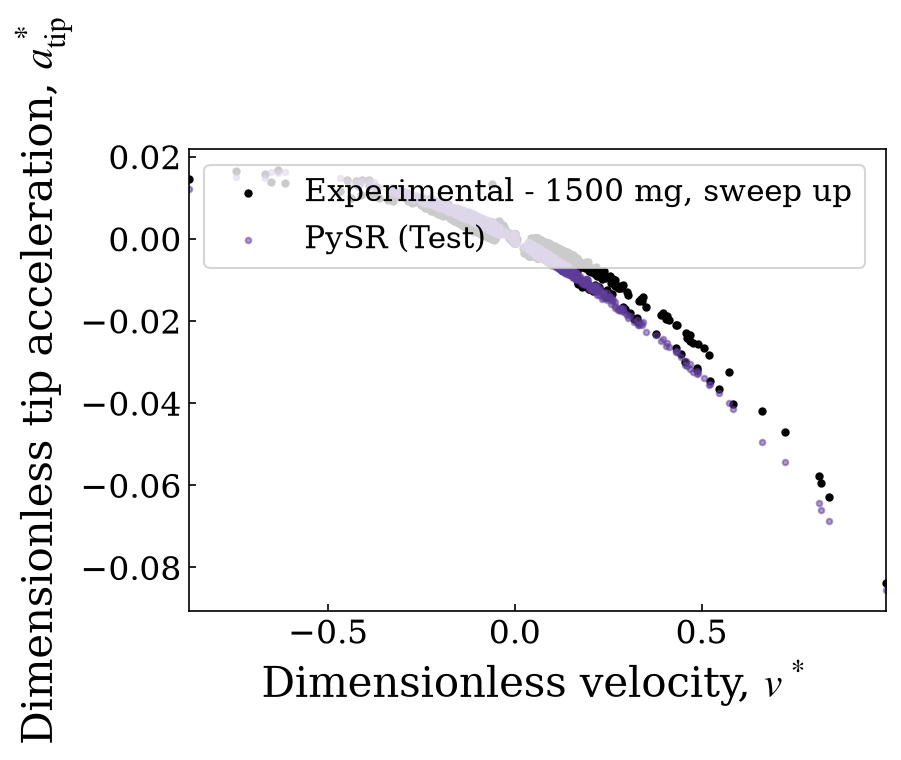

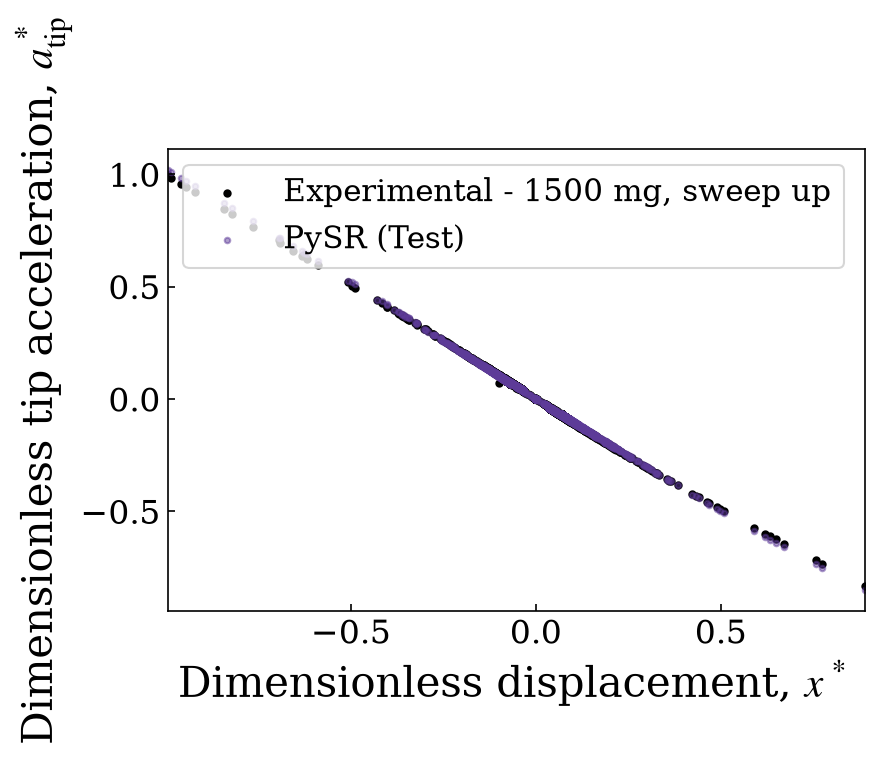

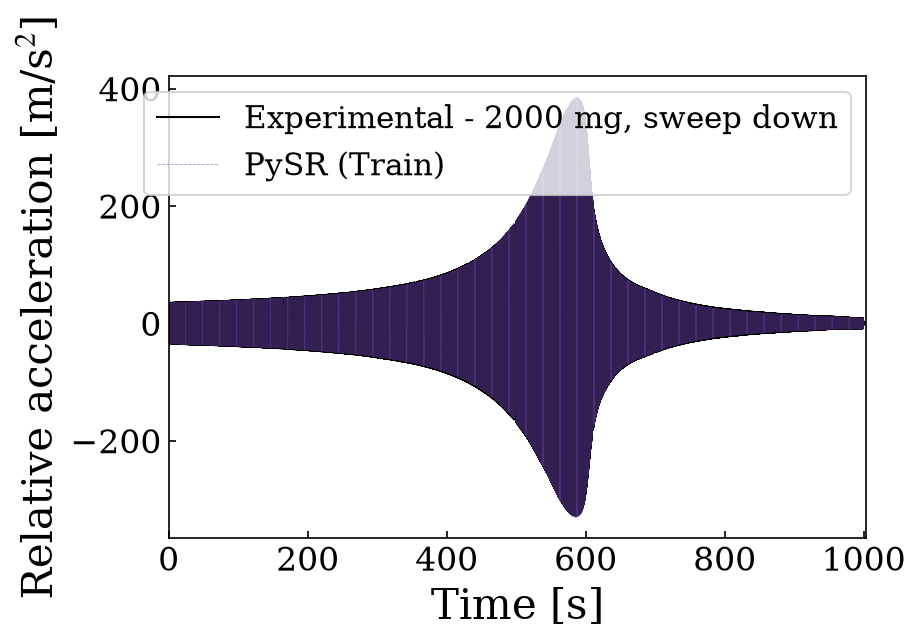

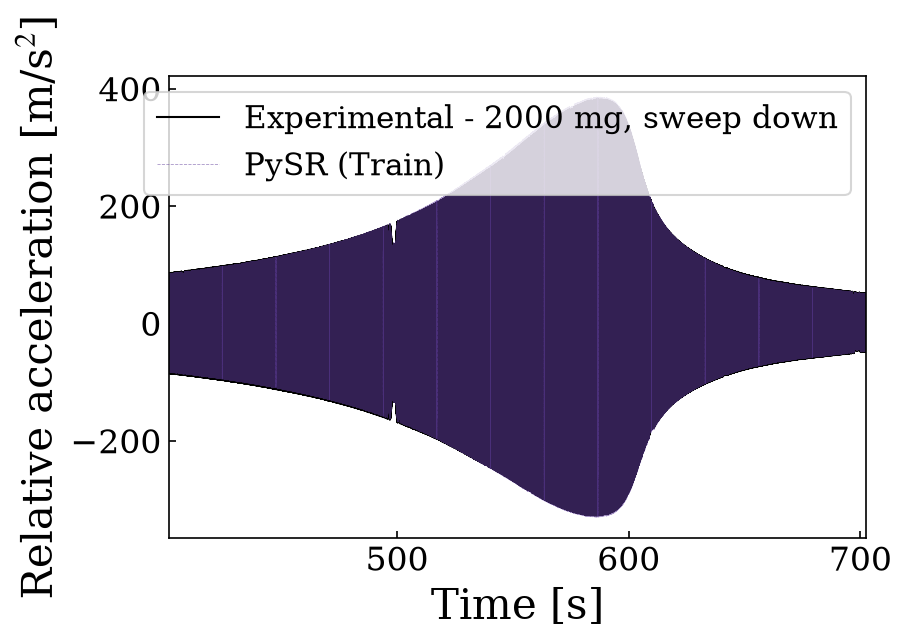

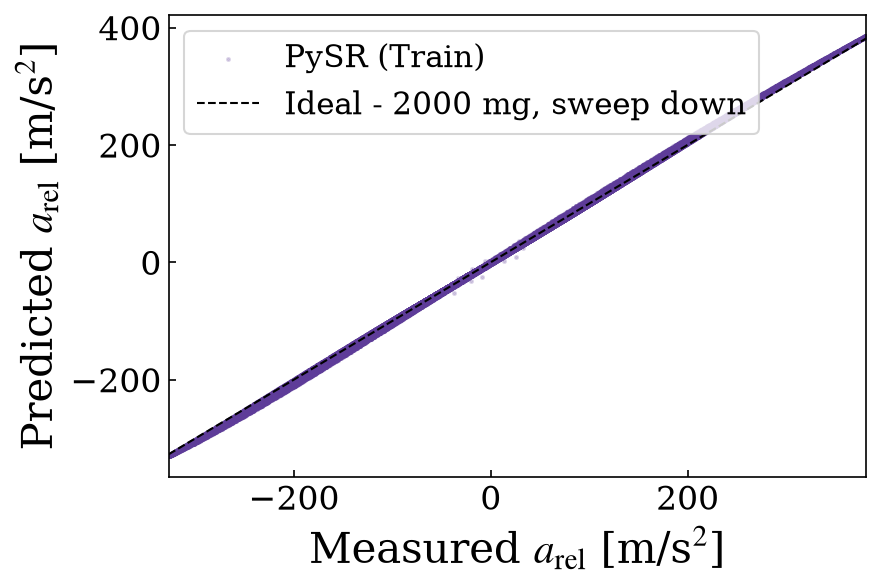

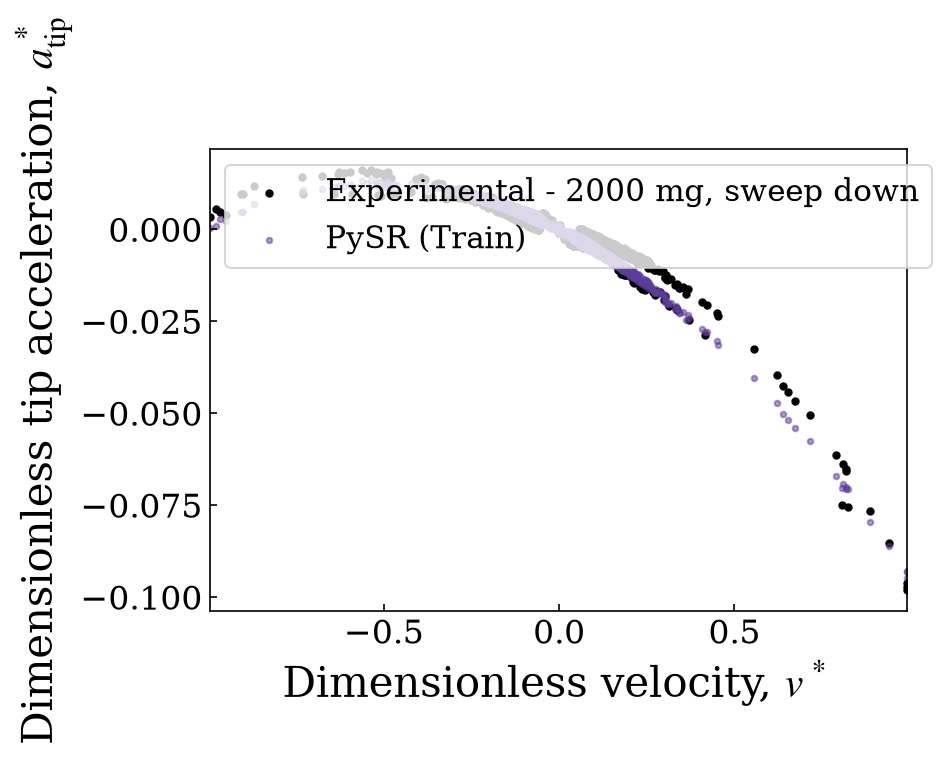

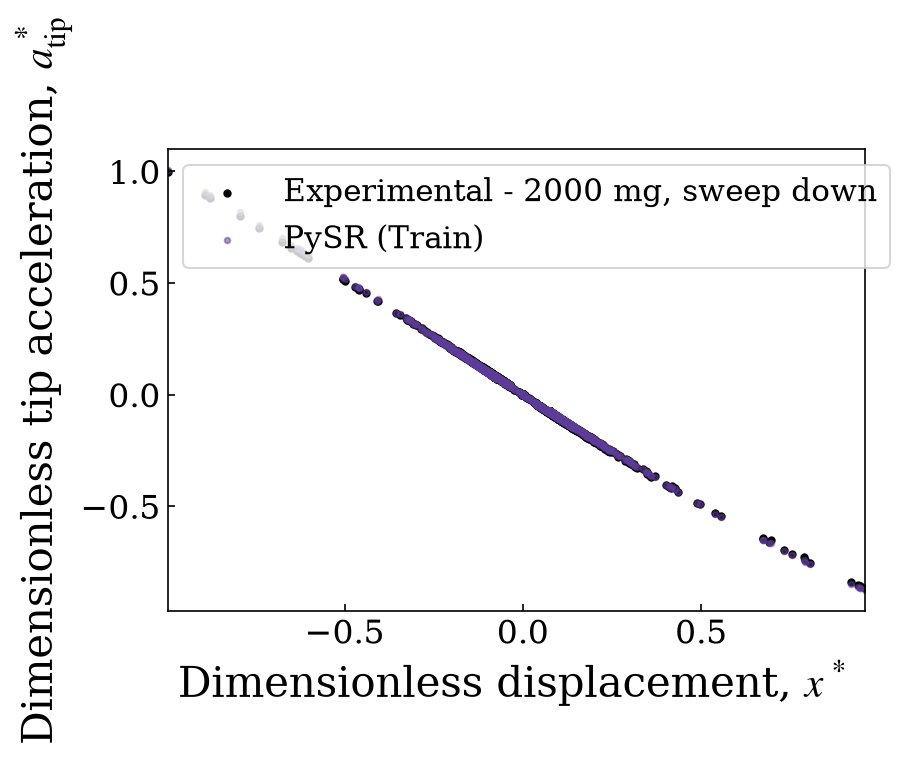

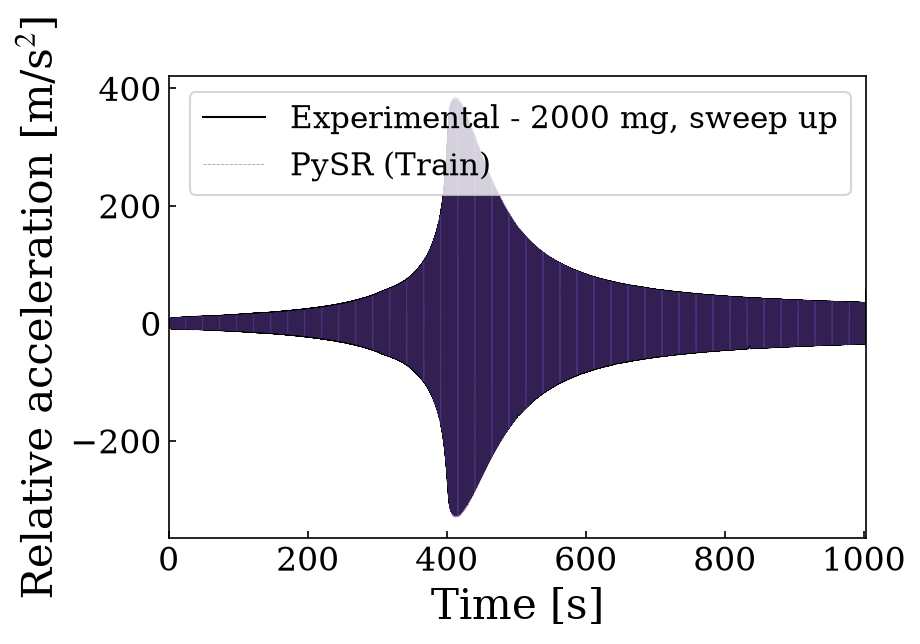

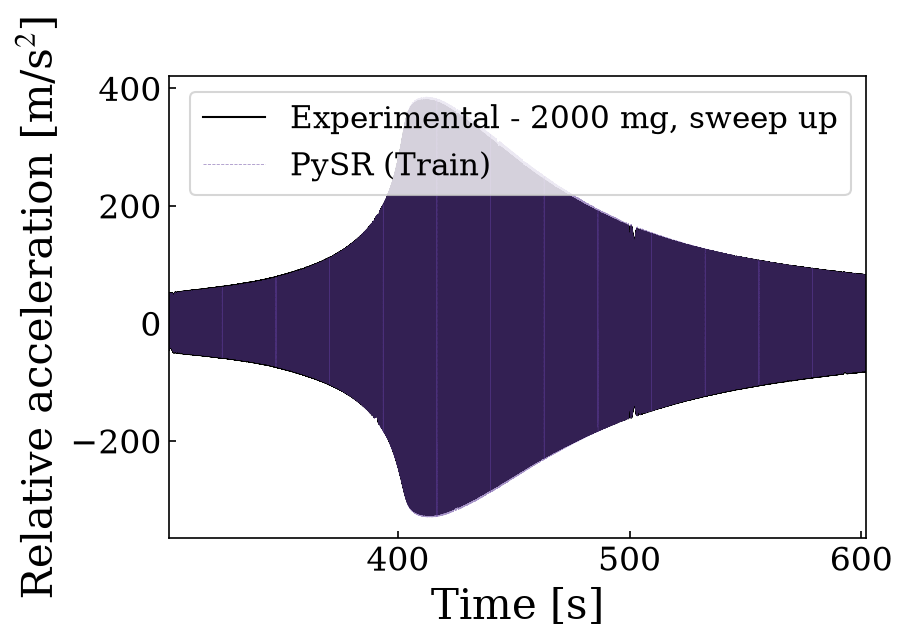

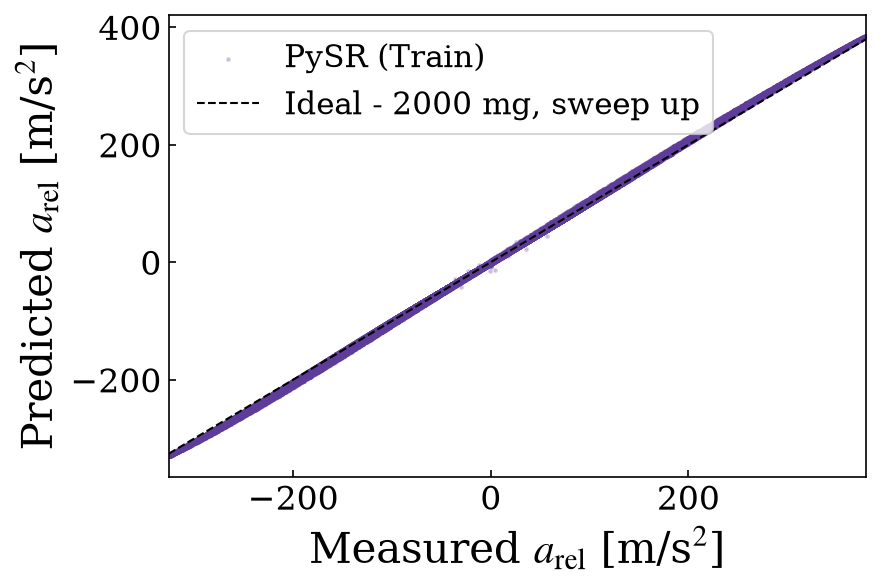

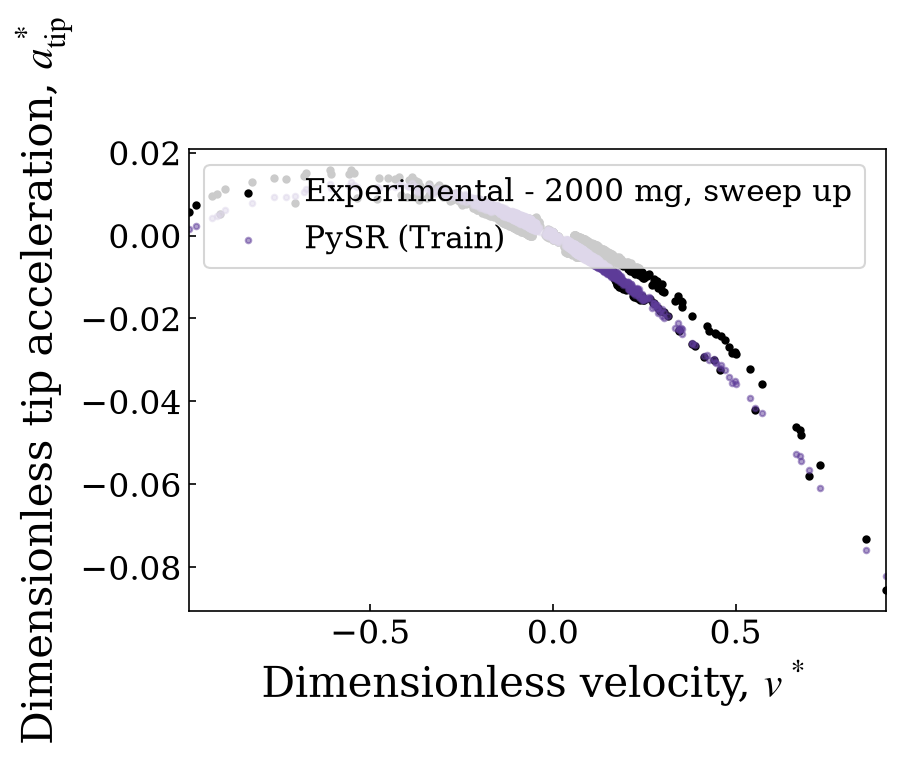

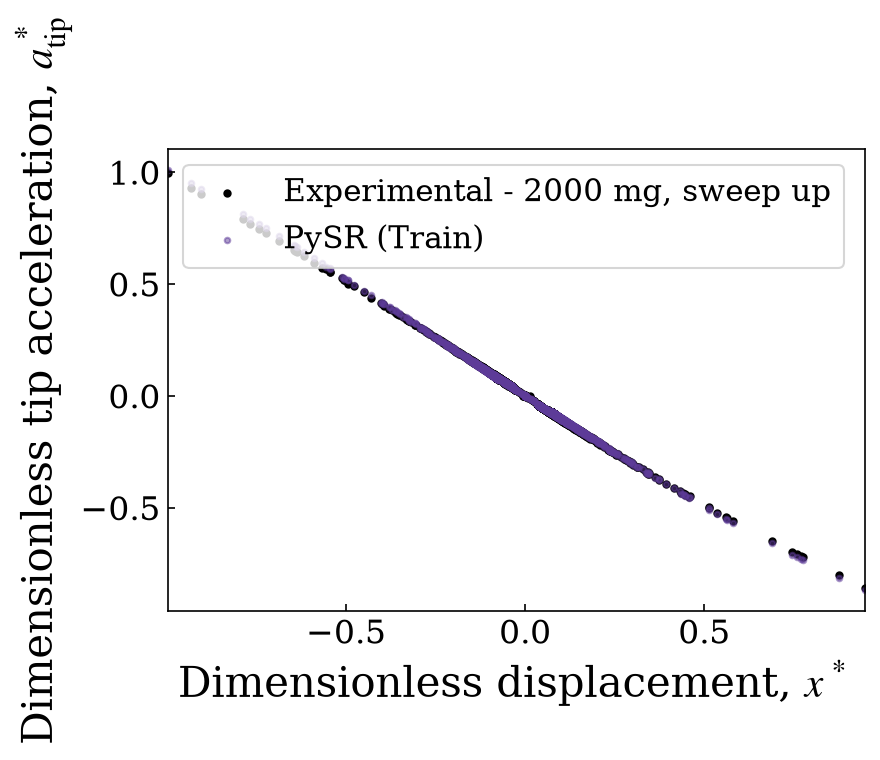

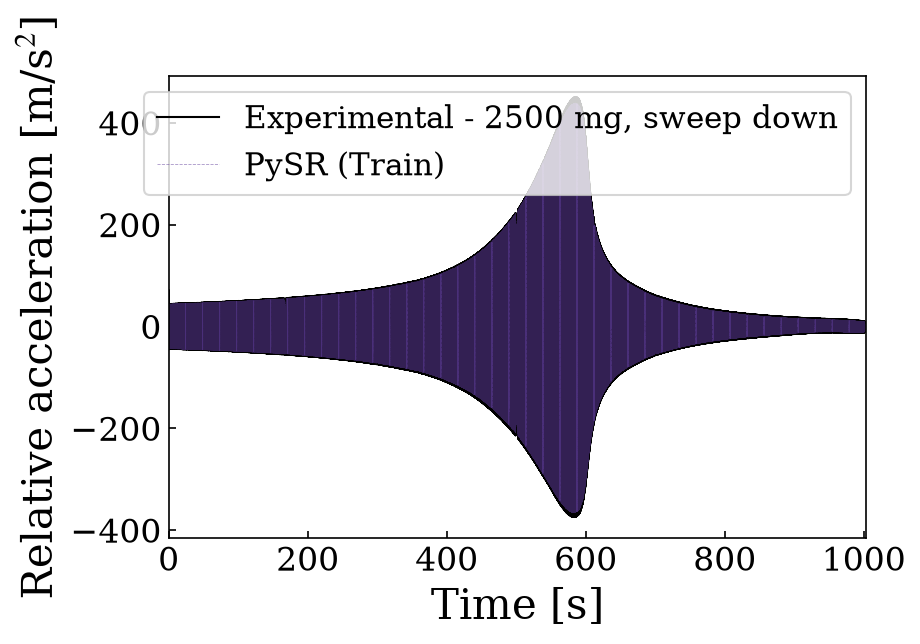

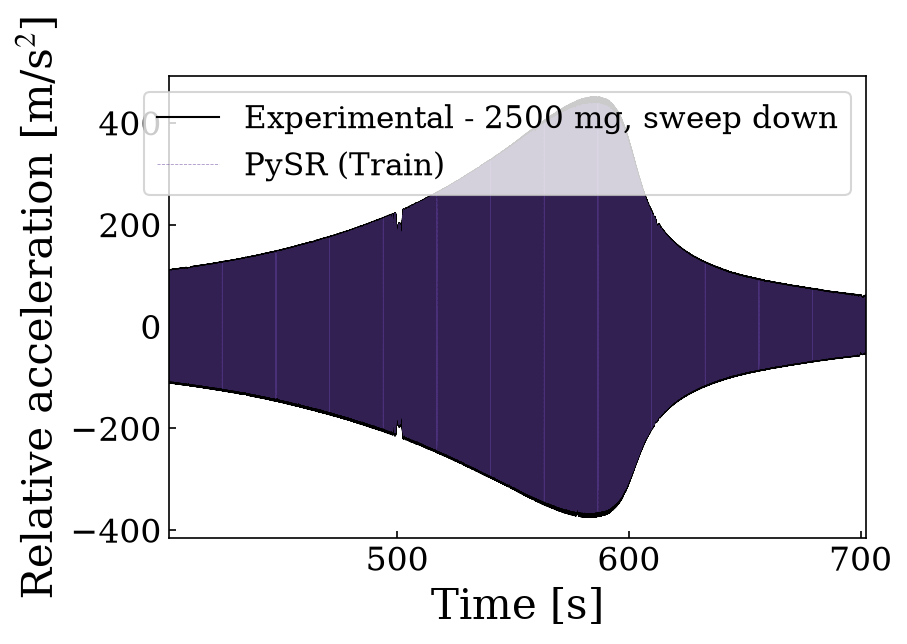

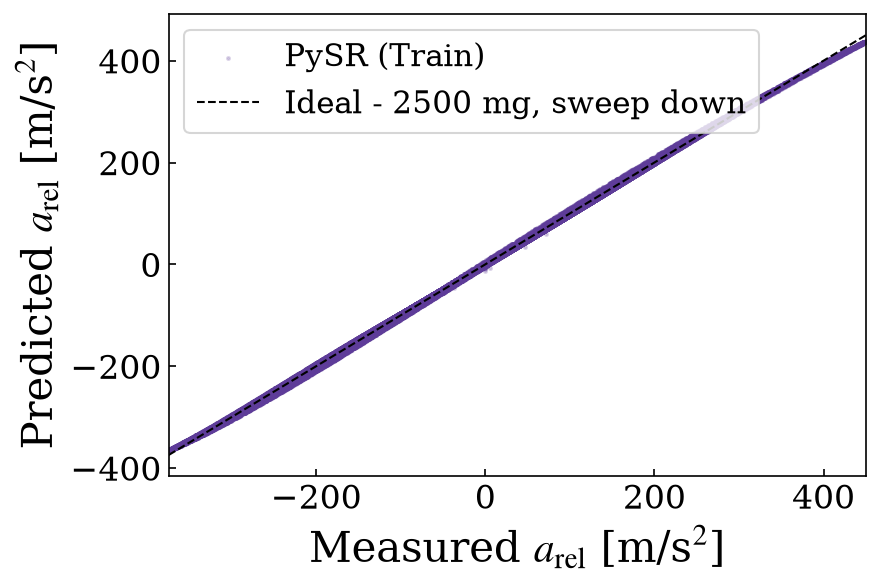

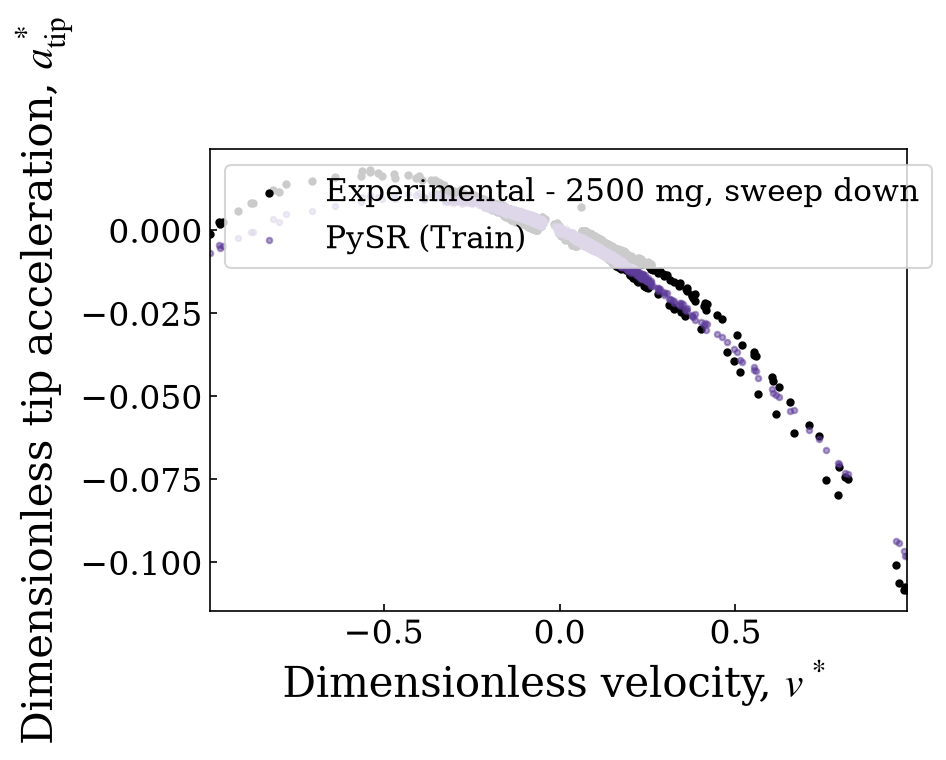

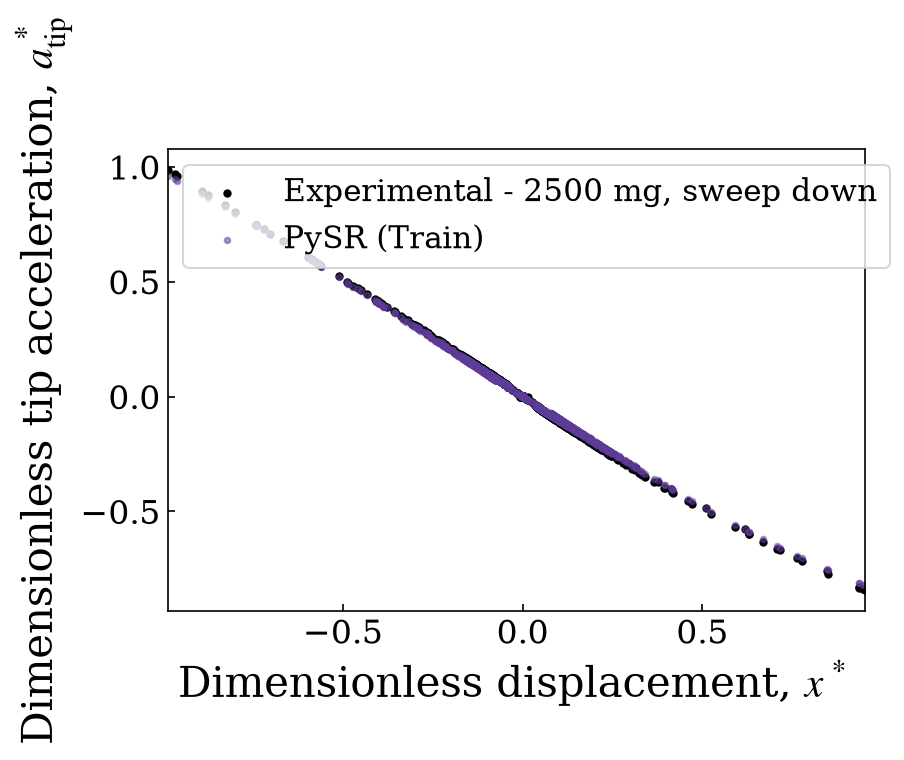

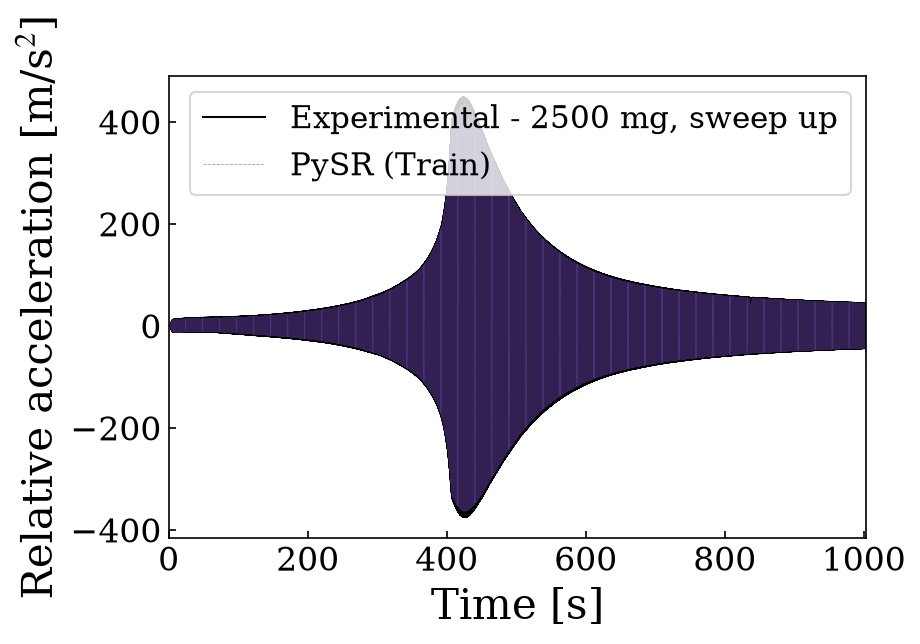

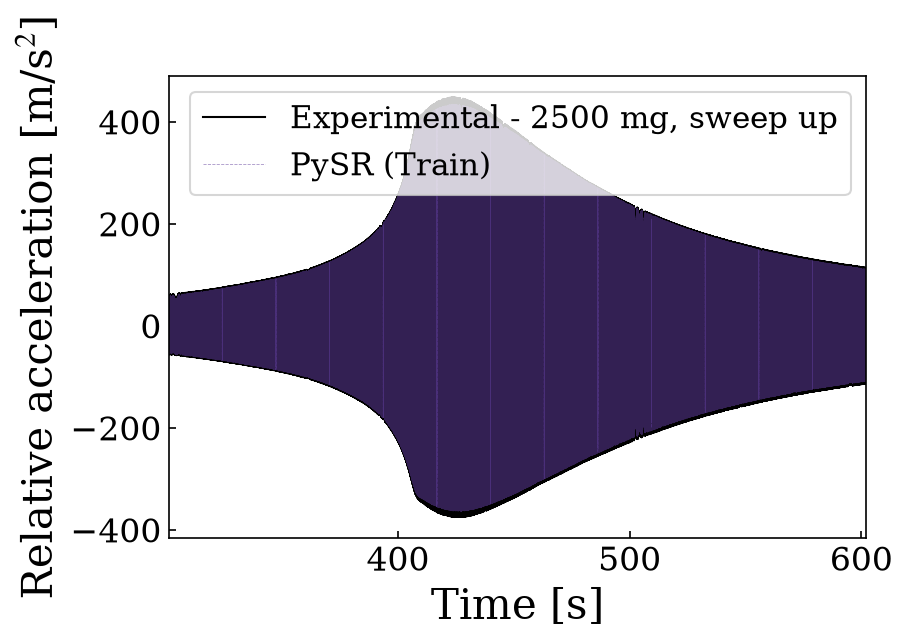

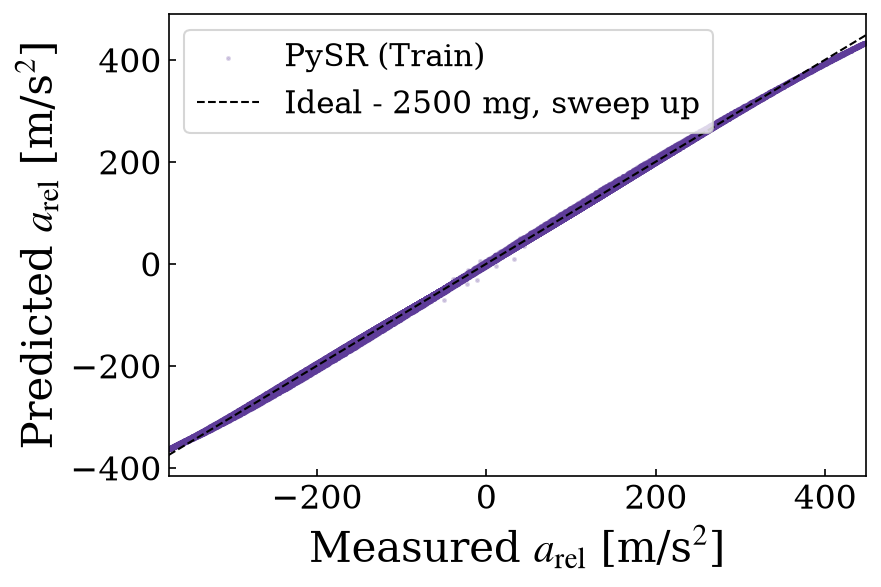

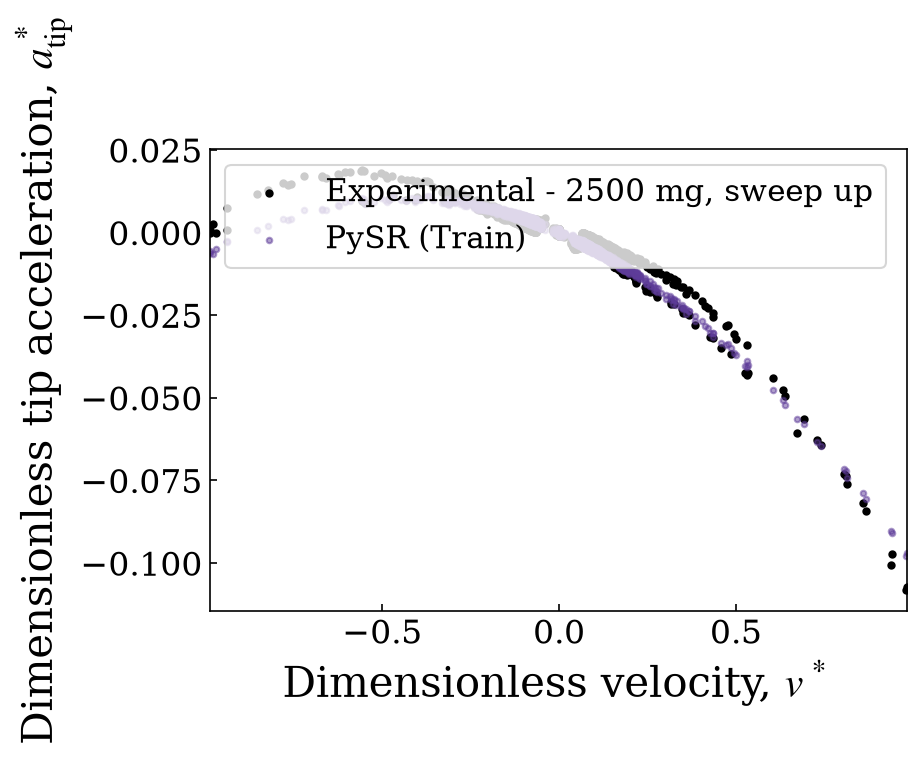

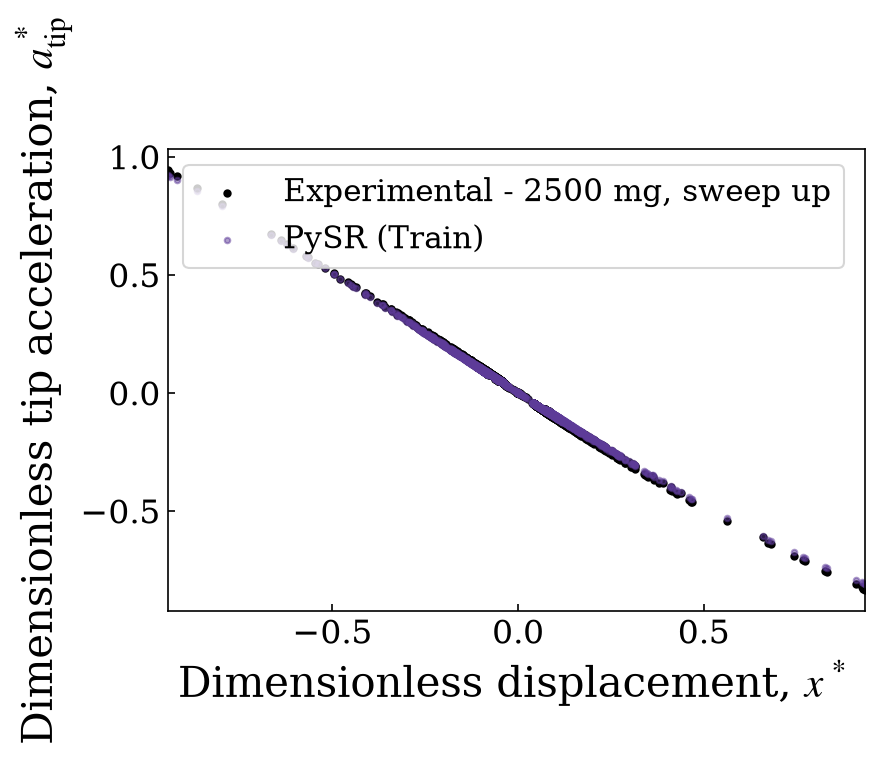

In [17]:
dimensionless_scales = plot_diagnostics(one_step_series, FIGURES_DIR)

## 13. Save results

Writes `pysr_results.pkl`, `pysr_equation.json`, `pysr_run_manifest.json`, `pysr_front.csv` and `pysr_search_history.csv` to `results/`; PySR's own files are in `results/pysr_search/4_pysr/`.

In [18]:
jl.seval("import Pkg")
julia_packages = str(jl.seval("sprint(io -> Pkg.status(; io=io, mode=Pkg.PKGMODE_MANIFEST))"))
serializable_settings = {key: (value if key != "loss_function" else "polynomial_space_loss (see search_space)")
                         for key, value in PYSR_SETTINGS.items()}
equation_record = {
    "physical_expression": str(selected_expression),
    "variables": FEATURE_NAMES, "terms": selected_terms, "number_of_terms": len(selected_terms),
    "native_equation_scaled": selected_equation, "native_complexity": int(selected_row["complexity"]),
    "native_complexity_definition": "number of nodes of the PySR expression tree",
    "scaled_terms": selected_analysis["scaled_terms"],
    "coefficients": "native PySR constants, expanded exactly into SI units (no refit)",
    "pysr_loss": float(selected_row["loss"]), "equation_index": selected_index,
    "physical_diagnostics": selected_diagnostics,
    "training_metrics": {key: float(selected_row[key]) for key in
                         ["training_NRMSE", "training_resonance_NRMSE", "training_score"]},
    "selection": "common rule on the PySR Pareto front (fewest terms within 10 % of the best admissible score)",
    "reference_score": reference_score, "within_10_percent_of_dense_least_squares": bool(within_dense),
    "dense_reference": DENSE_REFERENCE,
    "pysr_model_selection_best": {"equation": pysr_model.equations_.loc[pysr_best_index, "equation"],
                                  "complexity": int(pysr_best_row["complexity"]),
                                  "number_of_terms": int(pysr_best_row["number_of_terms"])},
}
run_manifest = {
    "prepared_sha256": prepared_hash,
    "python": sys.version, "platform": platform.platform(),
    "packages": {name: version(name) for name in ["pysr", "numpy", "scipy", "sympy", "pandas", "juliacall"]},
    "julia_version": str(jl.seval("string(VERSION)")),
    "symbolic_regression_jl": str(jl.seval("string(pkgversion(SymbolicRegression))")),
    "julia_packages": julia_packages,
    "deterministic_search": True, "determinism_check_run": RUN_DETERMINISM_CHECK,
    "pysr_settings": serializable_settings,
    "search_blocks": SEARCH_BLOCKS, "iterations_per_block": ITERATIONS_PER_BLOCK,
    "total_iterations": SEARCH_BLOCKS * ITERATIONS_PER_BLOCK,
    "search_seconds": search_seconds, "block_seconds": block_times,
    "search_space": {"source": "PySINDy library at the degree selected by 4_pysindy.ipynb on the training levels",
                     "max_polynomial_degree": POLYNOMIAL_DEGREE, "max_input_power": MAX_INPUT_POWER,
                     "monomials": [monomial_name(*p) for p in POLY_POWERS], "loss_function": POLYNOMIAL_SPACE_LOSS},
    "scaling": {"feature_scales": dict(zip(FEATURE_NAMES, map(float, feature_scales))), "target_scale": target_scale,
                "definition": "standard deviation (ddof=0) over all training samples"},
    "training_samples": int(len(y_train)),
    "pysr_run_directory": str(Path(pysr_model.output_directory_) / pysr_model.run_id_),
}
configuration = {
    "levels_mg": LEVELS_MG,
    "protocol": PROTOCOL_DESCRIPTION,
    "regression_step": 1,
    "fit_sampling": "all training samples (PySR batching: minibatches of all samples during evolution, "
                    "full data for the hall of fame)",
    "training_sample_count": int(len(y_train)),
    "max_polynomial_degree": POLYNOMIAL_DEGREE, "max_input_power": MAX_INPUT_POWER,
    "polynomial_degree_source": "4_pysindy.ipynb degree study on the training levels",
    "allow_constant_term": False, "maxsize": PYSR_SETTINGS["maxsize"],
    "acceptable_error_increase": ACCEPTABLE_ERROR_INCREASE,
    "sweep_min_hz": SWEEP_MIN_HZ, "sweep_max_hz": SWEEP_MAX_HZ, "resonance_band_hz": RESONANCE_BAND_HZ,
    "total_error_weight": TOTAL_ERROR_WEIGHT, "resonance_error_weight": RESONANCE_ERROR_WEIGHT,
    "random_state": RANDOM_STATE, "total_iterations": SEARCH_BLOCKS * ITERATIONS_PER_BLOCK,
    "plot_window_s": None,
    "evaluation_mode": "measured-state acceleration",
    "selection_mode": "common criterion on the PySR Pareto front: smallest number of polynomial terms within "
                      "ACCEPTABLE_ERROR_INCREASE of the best admissible training score (0.3 pooled NRMSE + 0.7 pooled "
                      "resonance NRMSE) on the training levels; physical checks: restoring force, damping, input term",
    "method": "single deterministic PySR search on all training samples; native PySR coefficients",
}
selection_summary = pd.DataFrame([{
    "run": f"training levels {TRAINING_LEVELS_MG} mg", "fit_levels_mg": TRAINING_LEVELS_MG,
    "test_level_mg": TEST_LEVEL_MG, "polynomial_degree": POLYNOMIAL_DEGREE,
    "iterations": SEARCH_BLOCKS * ITERATIONS_PER_BLOCK, "front_size": len(final_front),
    "number_of_terms": len(selected_terms), "native_complexity": int(selected_row["complexity"]),
    "training_score": float(selected_row["training_score"]), "reference_score": reference_score,
    "dense_reference_score": DENSE_REFERENCE["training_score"], "within_dense_tolerance": bool(within_dense),
    "physically_valid": bool(selected_diagnostics["physically_valid"]),
    "stable_blocks": stable_blocks, "v_dot": str(selected_expression), "search_minutes": search_seconds / 60}])
display(selection_summary)

pysr_results = {
    "schema_version": 7,
    "source_prepared_file": str(PREPARED_FILE.resolve()),
    "configuration": configuration,
    "run_manifest": run_manifest,
    "protocol": {"levels_mg": LEVELS_MG, "test_level_mg": TEST_LEVEL_MG, "training_levels_mg": TRAINING_LEVELS_MG,
                 "split": split_summary, "roles": ROLES, "description": PROTOCOL_DESCRIPTION},
    "signal_names": [s["name"] for s in all_signals],
    "settings_table": settings_table,
    "equation": equation_record,
    "pareto_front": final_front,
    "block_fronts": pd.concat(block_fronts, ignore_index=True),
    "search_history": search_history,
    "selection_summary": selection_summary,
    "term_contributions": term_contributions,
    "physical_comparison": physical_table,
    "comparison_with_pysindy": comparison_with_pysindy,
    "one_step": {"per_signal_metrics": one_step_metrics, "per_level": one_step_per_level,
                 "aggregate_metrics": one_step_aggregate, "series": one_step_series},
    "dimensionless_scales": dimensionless_scales,
}
with (RESULTS_DIR / "pysr_results.pkl").open("wb") as file:
    pickle.dump(pysr_results, file, protocol=pickle.HIGHEST_PROTOCOL)
(RESULTS_DIR / "pysr_run_manifest.json").write_text(json.dumps(run_manifest, indent=2, default=str), encoding="utf-8")
portable_equation = {key: equation_record[key] for key in
                     ["physical_expression", "variables", "terms", "number_of_terms", "native_equation_scaled",
                      "native_complexity", "coefficients", "training_metrics"]}
portable_equation.update(scaling=run_manifest["scaling"], method=configuration["method"])
(RESULTS_DIR / "pysr_equation.json").write_text(json.dumps(portable_equation, indent=2, default=str), encoding="utf-8")
final_front.to_csv(RESULTS_DIR / "pysr_front.csv", index=False)
search_history.to_csv(RESULTS_DIR / "pysr_search_history.csv", index=False)
for stale in ("pysr_candidate_audit.json",):  # obsolete file from an earlier version
    (RESULTS_DIR / stale).unlink(missing_ok=True)
print("Saved results, equation, front, search history and run manifest to", RESULTS_DIR)

,run,fit_levels_mg,test_level_mg,polynomial_degree,iterations,front_size,number_of_terms,native_complexity,training_score,reference_score,dense_reference_score,within_dense_tolerance,physically_valid,stable_blocks,v_dot,search_minutes
0,"training levels (500, 1000, 2000, 2500) mg","(500, 1000, 2000, 2500)",1500,5,100,16,6,35,0.02282,0.02282,0.014633,False,True,8,-1.05805763785504*u - 45.8986728017359*v**2 - ...,10.729804


Saved results, equation, front, search history and run manifest to C:\Users\bruno\Downloads\BEPE (2)\BEPE\results
